<a href="https://colab.research.google.com/github/Tapiwanashe6/swahili-news-classification/blob/main/formative_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Swahili News Classification
## Research-Informed Sequential Models for NLP and Language Technologies

### 1. Introduction and Dataset

This project investigates **multiclass classification of Swahili news articles**. The objective is to determine how effectively classical lexical methods, task-specific sequential neural networks, and a pretrained multilingual Transformer can classify an article into one of six categories:

- **afya** — health
- **burudani** — entertainment
- **kimataifa** — international news
- **kitaifa** — national news
- **michezo** — sports
- **uchumi** — economy/business

The training file used in this investigation contains **23,268 records** with three variables: `id`, `content`, and `category`. The exact structure and class frequencies are verified empirically in the following section rather than assumed from an external challenge description.

This is a **multiclass Natural Language Processing (NLP) classification problem** and is directly relevant to sequential modelling because each article can be represented as an ordered sequence of words, tokens, or subwords. Word order, local phrases, long-range context, and lexical choice may all provide information about an article's category.

The practical motivation is automatic organization of Swahili-language news. Reliable classification can support indexing, retrieval, recommendation, and content management, while also providing a useful setting for studying NLP methods in an African-language context.

**Research question:** *How effectively can different lexical, recurrent, convolutional, and Transformer-based approaches classify Swahili news articles, and what do their errors reveal about the strengths and limitations of sequential modelling for this dataset?*


In [ ]:
# Reproducibility setup — run before all experiments
import os, random, numpy as np
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
random.seed(SEED)
np.random.seed(SEED)
print(f"Global random seed set to {SEED}. Neural results should be more stable, although tiny hardware/library differences can still occur.")


## 2. Loading and Understanding the Dataset

Before performing exploratory analysis or preprocessing, the training dataset was loaded and inspected to understand its structure. We examine its dimensions, column names, data types, and a sample of observations.

This initial inspection helps verify that the dataset contains the expected text and target variables before further analysis is performed.

In [ ]:
# Import required library
import pandas as pd

# Load the training dataset
df = pd.read_csv("/train.csv")

print("Dataset loaded successfully.")

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

# Display first five observations
df.head()

Dataset loaded successfully.

Dataset shape:
(23268, 3)

Column names:
['id', 'content', 'category']

Data types:
id          object
content     object
category    object
dtype: object


,id,content,category
0,SW4670,"Bodi ya Utalii Tanzania (TTB) imesema, itafan...",uchumi
1,SW30826,"PENDO FUNDISHA-MBEYA RAIS Dk. John Magufuri, ...",kitaifa
2,SW29725,Mwandishi Wetu -Singida BENKI ya NMB imetoa ms...,uchumi
3,SW20901,"TIMU ya taifa ya Tanzania, Serengeti Boys jan...",michezo
4,SW12560,Na AGATHA CHARLES – DAR ES SALAAM ALIYEKUWA K...,kitaifa


### Initial Dataset Observations

The loaded dataset contains **23,268 news articles and three variables: `id`, `content`, and `category`**.

- `id` identifies each news record.
- `content` contains the textual content of the Swahili news article and will serve as the main input to the classification models.
- `category` contains the target news category that the models will attempt to predict.

All three variables are represented as text (`object`) in the dataset. The `id` variable is an identifier rather than a linguistic feature and therefore will not be used as a predictor during model development.

Initial inspection confirms that the `content` field contains Swahili news text and that the `category` field contains news labels such as `kitaifa`, `michezo`, and `uchumi`.

The dataset therefore represents a **multiclass text-classification problem**, where the objective is to predict a news category from the sequence of words contained in each article.

In [ ]:
df["category"].unique()
df["category"].nunique()
df["category"].value_counts()

,count
category,
kitaifa,10242
michezo,6004
burudani,2229
uchumi,2028
kimataifa,1906
afya,859


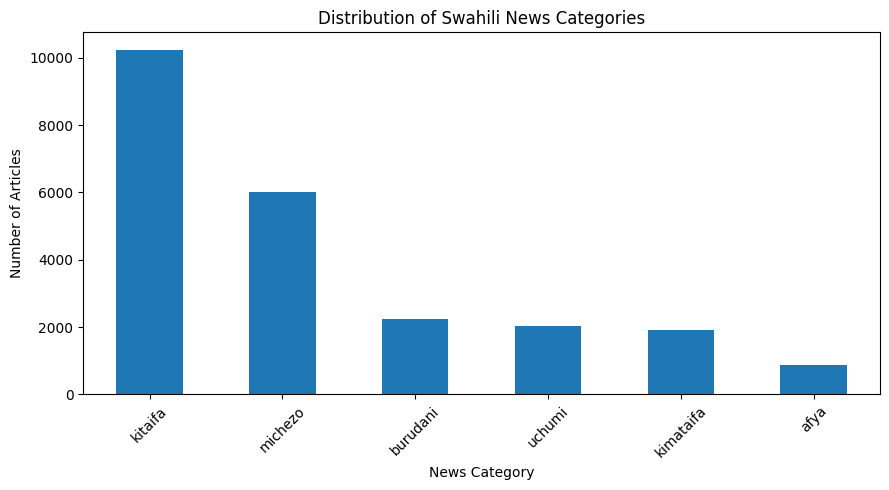

In [ ]:
import matplotlib.pyplot as plt

class_counts = df["category"].value_counts()

plt.figure(figsize=(9, 5))
class_counts.plot(kind="bar")

plt.title("Distribution of Swahili News Categories")
plt.xlabel("News Category")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Class Distribution Findings

The dataset contains **six news categories** and exhibits substantial class imbalance. `Kitaifa` is the largest category with 10,242 articles (approximately 44% of the dataset), followed by `michezo` with 6,004 articles (approximately 26%). In contrast, `afya` contains only 859 articles (approximately 4%).

The largest category therefore contains almost twelve times as many observations as the smallest category. This imbalance is important because a model may achieve relatively high overall accuracy by performing well on the majority classes while performing poorly on less represented categories such as `afya`.

Consequently, **accuracy alone will not be sufficient for evaluating the models**. Later experiments should also consider class-sensitive metrics such as precision, recall, per-class F1-score, and macro-averaged F1. Macro-F1 will be particularly useful because it gives equal importance to each category regardless of its frequency.

The class imbalance may also influence model training. Rather than immediately modifying the class distribution, balancing strategies such as class weighting can later be investigated experimentally and compared against an unweighted baseline.

## 4. Data Quality and Duplicate Analysis

Before preprocessing and splitting the dataset, we examine the data for missing values, empty text, duplicate identifiers, duplicate articles, and potentially conflicting labels.

Duplicate articles are particularly important because copies of the same article appearing across training and evaluation sets could introduce data leakage and produce overly optimistic estimates of model performance.

In [ ]:
# ==========================================
# DATA QUALITY CHECKS
# ==========================================

print("MISSING VALUES")
print(df.isnull().sum())

print("\nEMPTY/BLANK CONTENT:")
blank_content = df["content"].fillna("").str.strip().eq("").sum()
print(blank_content)

print("\nEMPTY/BLANK CATEGORY:")
blank_category = df["category"].fillna("").str.strip().eq("").sum()
print(blank_category)

print("\nEMPTY/BLANK ID:")
blank_id = df["id"].fillna("").str.strip().eq("").sum()
print(blank_id)

MISSING VALUES
id          0
content     0
category    0
dtype: int64

EMPTY/BLANK CONTENT:
1

EMPTY/BLANK CATEGORY:
0

EMPTY/BLANK ID:
0


In [ ]:
duplicate_ids = df["id"].duplicated().sum()

print("Duplicate IDs:", duplicate_ids)

if duplicate_ids > 0:
    display(
        df[df["id"].duplicated(keep=False)]
        .sort_values("id")
        .head(20)
    )

Duplicate IDs: 0


In [ ]:
duplicate_content = df["content"].duplicated().sum()

print("Duplicate article texts:", duplicate_content)
print(
    f"Percentage duplicated: "
    f"{duplicate_content / len(df) * 100:.2f}%"
)

Duplicate article texts: 1061
Percentage duplicated: 4.56%


In [ ]:
# Number of different categories assigned to each article text
label_counts_per_text = df.groupby("content")["category"].nunique()

conflicting_texts = label_counts_per_text[
    label_counts_per_text > 1
]

print("Unique article texts appearing under multiple categories:",
      len(conflicting_texts))

Unique article texts appearing under multiple categories: 271


In [ ]:
if len(conflicting_texts) > 0:

    conflict_examples = df[
        df["content"].isin(conflicting_texts.index)
    ].sort_values("content")

    display(
        conflict_examples[
            ["id", "category", "content"]
        ].head(20)
    )

,id,category,content
11755,SW6857,kitaifa,\n\t \n \n\t \n \nNA VERONICA ROMWALD– DAR ES ...
3425,SW7937,afya,\n\t \n \n\t \n \nNA VERONICA ROMWALD– DAR ES ...
1372,SW14432,kitaifa,"\n\t \n \n\t \n \nNa Mwandishi Wetu,\n \n\tJUN..."
2076,SW25983,afya,"\n\t \n \n\t \n \nNa Mwandishi Wetu,\n \n\tJUN..."
12645,SW22139,michezo,\n\n \n\tNa ADAM MKWEPU-DAR ES SALAAM\n \n\tLI...
22468,SW23767,kitaifa,\n\n \n\tNa ADAM MKWEPU-DAR ES SALAAM\n \n\tLI...
13580,SW23814,kitaifa,\n\n \n\tNa CHRISTOPHER MSEKENA\n \n\tTASNIA y...
4529,SW20316,burudani,\n\n \n\tNa CHRISTOPHER MSEKENA\n \n\tTASNIA y...
9407,SW20070,afya,"\n\n \n\tNa MWANDISHI WETU, DAR ES SALAAM\n \n..."
11576,SW13047,kitaifa,"\n\n \n\tNa MWANDISHI WETU, DAR ES SALAAM\n \n..."


In [ ]:
print("=" * 50)
print("DATA QUALITY SUMMARY")
print("=" * 50)

print(f"Total records:             {len(df):,}")
print(f"Missing content:           {df['content'].isnull().sum():,}")
print(f"Blank content:             {blank_content:,}")
print(f"Duplicate IDs:             {duplicate_ids:,}")
print(f"Duplicate article texts:   {duplicate_content:,}")
print(f"Conflicting article texts: {len(conflicting_texts):,}")

DATA QUALITY SUMMARY
Total records:             23,268
Missing content:           0
Blank content:             1
Duplicate IDs:             0
Duplicate article texts:   1,061
Conflicting article texts: 271


### Data Quality Findings and Preprocessing Decision

The dataset contains 23,268 records and is largely complete. No missing values were found in the article content or target category, no duplicate identifiers were identified, and only one record contained blank article content.

Duplicate analysis, however, identified **1,061 duplicate article rows**, representing approximately **4.6% of the dataset**. This is important because identical articles distributed across training and evaluation sets could introduce data leakage and lead to overly optimistic estimates of model generalization.

A further analysis identified **271 unique article texts associated with more than one category label**. These cases represent conflicting supervision: identical textual input is mapped to different target categories. Such observations introduce ambiguity during training and evaluation because the model cannot consistently learn two different labels for exactly the same input.

Based on these findings, data-quality cleaning will be performed before the train-validation-test split. Blank articles will be removed, articles associated with conflicting labels will be excluded because the available data does not provide sufficient evidence for selecting the correct label, and remaining same-label duplicate articles will be reduced to a single observation.

Performing these operations before splitting the data reduces the risk of duplicate-based leakage and provides a cleaner basis for evaluating how well the models generalize to previously unseen articles.

## 5. Distribution of Duplicate and Conflicting Articles

Because the dataset is already class-imbalanced, removing duplicate and conflicting observations may affect some categories more than others. Before cleaning the dataset, we therefore examine how these problematic observations are distributed across the six news categories.

This analysis helps determine whether the proposed cleaning strategy disproportionately reduces any minority class.

In [ ]:
# ==========================================
# EFFECT OF LABEL CONFLICTS ON EACH CATEGORY
# ==========================================

# 1. Find article texts that have more than one category
category_counts_per_text = df.groupby("content")["category"].nunique()

conflicting_texts = category_counts_per_text[
    category_counts_per_text > 1
].index

# 2. Get every row belonging to those conflicting articles
conflicting_rows = df[
    df["content"].isin(conflicting_texts)
].copy()

# 3. Count conflicting rows by category
conflict_counts = conflicting_rows["category"].value_counts()

# 4. Original category sizes
original_counts = df["category"].value_counts()

# 5. Create comparison table
conflict_impact = pd.DataFrame({
    "original_articles": original_counts,
    "conflicting_rows": conflict_counts
}).fillna(0)

conflict_impact["conflicting_rows"] = (
    conflict_impact["conflicting_rows"].astype(int)
)

# 6. Percentage of each category affected
conflict_impact["percentage_affected"] = (
    conflict_impact["conflicting_rows"]
    / conflict_impact["original_articles"]
    * 100
).round(2)

print("Unique article texts with conflicting labels:",
      len(conflicting_texts))

print("\nTotal rows involved in label conflicts:",
      len(conflicting_rows))

print("\nConflicting rows by category:")
print(conflict_counts)

print("\nImpact on each category:")
display(conflict_impact)

Unique article texts with conflicting labels: 271

Total rows involved in label conflicts: 630

Conflicting rows by category:
category
kitaifa      177
afya         155
kimataifa     86
burudani      83
uchumi        82
michezo       47
Name: count, dtype: int64

Impact on each category:


,original_articles,conflicting_rows,percentage_affected
category,,,
afya,859,155,18.04
burudani,2229,83,3.72
kimataifa,1906,86,4.51
kitaifa,10242,177,1.73
michezo,6004,47,0.78
uchumi,2028,82,4.04


### Impact of Label Conflicts Across Categories

Label conflicts were not distributed evenly across the six news categories. In total, 630 rows were associated with the 271 unique article texts that received multiple category labels.

The most notable result was observed for the `afya` category. Of its 859 observations, 155 (18.04%) were involved in label conflicts. This proportion was substantially higher than for `kimataifa` (4.51%), `uchumi` (4.04%), `burudani` (3.72%), `kitaifa` (1.73%), and `michezo` (0.78%).

This finding is particularly important because `afya` is already the smallest class in the dataset. Removing every conflicting observation would reduce this category from 859 to approximately 704 observations before other duplicate-removal steps are considered, potentially increasing the existing class imbalance.

The concentration of conflicts within `afya` may also indicate that some articles contain themes that overlap multiple news categories, although the present analysis cannot determine whether the conflicts result from genuine topic ambiguity, annotation inconsistency, or another aspect of the dataset construction.

Therefore, conflicting observations should not be removed automatically without further investigation.

In [ ]:
from collections import Counter
from itertools import combinations

# Find the set of categories assigned to each conflicting article
conflict_category_sets = (
    df[df["content"].isin(conflicting_texts)]
    .groupby("content")["category"]
    .apply(lambda x: tuple(sorted(set(x))))
)

# Count category conflict combinations
conflict_pairs = Counter()

for categories in conflict_category_sets:
    for pair in combinations(categories, 2):
        conflict_pairs[pair] += 1

conflict_pairs_df = pd.DataFrame(
    [
        {
            "category_1": pair[0],
            "category_2": pair[1],
            "number_of_conflicting_articles": count
        }
        for pair, count in conflict_pairs.items()
    ]
).sort_values(
    "number_of_conflicting_articles",
    ascending=False
)

display(conflict_pairs_df)

,category_1,category_2,number_of_conflicting_articles
0,afya,kitaifa,134
5,burudani,kimataifa,49
3,burudani,michezo,18
2,burudani,kitaifa,17
4,afya,kimataifa,17
1,kitaifa,michezo,16
7,kimataifa,michezo,15
6,kimataifa,kitaifa,10
8,afya,burudani,3
11,afya,michezo,2


### Patterns in Conflicting Labels

Further analysis of the 271 conflicting article texts revealed that label disagreement is strongly concentrated within particular category pairs.

The most frequent conflict occurred between `afya` and `kitaifa`, with **134 identical articles appearing under both labels**. This was substantially higher than the next most frequent conflict, `burudani`–`kimataifa`, which occurred in 49 articles. Other conflicts were considerably less frequent.

This result explains much of the unusually high conflict rate previously observed for the `afya` category. Rather than being evenly distributed across categories, a large proportion of the ambiguity involving `afya` is specifically associated with `kitaifa`.

One possible explanation is thematic overlap between health and national news; however, the available data does not establish the cause of these conflicting annotations. They may reflect genuine topic overlap, annotation inconsistencies, or characteristics of how the dataset was constructed.

This ambiguity should therefore be considered both during preprocessing and later during error analysis, particularly when interpreting confusion between `afya` and `kitaifa`.

## 7. Article and Sequence Length Analysis

News articles vary in length, and this variation is important for sequential models because neural architectures typically require sequences to be padded or truncated to a chosen maximum length.

We therefore examine the number of words in each article, the overall distribution of article lengths, important length percentiles, and differences in article length across news categories. These findings will later inform the choice of sequence length used during model preprocessing.

In [ ]:
# Calculate article length using whitespace-separated words
df["word_count"] = df["content"].fillna("").apply(
    lambda text: len(str(text).split())
)

print("ARTICLE LENGTH STATISTICS")
print("=" * 40)

print(f"Minimum: {df['word_count'].min()} words")
print(f"Maximum: {df['word_count'].max()} words")
print(f"Mean:    {df['word_count'].mean():.2f} words")
print(f"Median:  {df['word_count'].median():.2f} words")

print("\nPercentiles:")
for p in [25, 50, 75, 90, 95, 99]:
    value = df["word_count"].quantile(p / 100)
    print(f"{p}th percentile: {value:.0f} words")

ARTICLE LENGTH STATISTICS
Minimum: 0 words
Maximum: 3840 words
Mean:    332.50 words
Median:  276.00 words

Percentiles:
25th percentile: 186 words
50th percentile: 276 words
75th percentile: 392 words
90th percentile: 584 words
95th percentile: 784 words
99th percentile: 1256 words


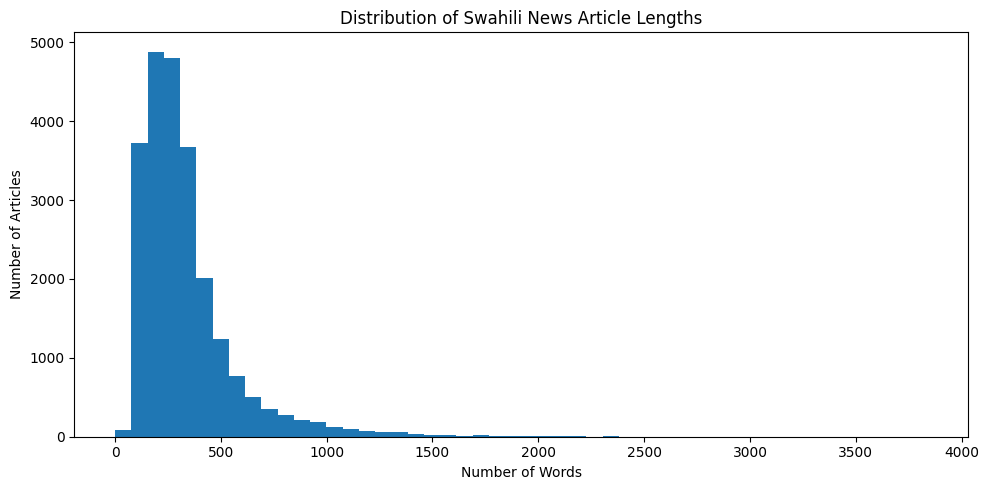

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    df["word_count"],
    bins=50
)

plt.title("Distribution of Swahili News Article Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Articles")

plt.tight_layout()
plt.show()

In [ ]:
category_percentiles = (
    df.groupby("category")["word_count"]
    .quantile([0.90, 0.95])
    .unstack()
    .rename(columns={
        0.90: "90th_percentile",
        0.95: "95th_percentile"
    })
    .round(0)
)

display(category_percentiles)

,90th_percentile,95th_percentile
category,,
afya,937.0,1151.0
burudani,524.0,628.0
kimataifa,552.0,790.0
kitaifa,697.0,923.0
michezo,457.0,593.0
uchumi,497.0,551.0


### Article-Length Findings and Modelling Implications

Article lengths are strongly right-skewed. The median article contains **276 words**, while the mean is higher at **332.5 words**, reflecting the presence of a smaller number of substantially longer articles. The 75th, 90th, and 95th percentiles are 392, 584, and 784 words respectively, while the longest article contains 3,840 words.

The minimum article length is zero, corresponding to the blank article previously identified during the data-quality analysis. This observation should be removed before model development because it contains no textual information from which a category can be predicted.

The distribution indicates that using the maximum observed article length as the sequence length would be inefficient. A sequence length of 3,840 would require extensive padding for the majority of articles, increasing memory and computational requirements unnecessarily.

Article lengths also differ across categories. `Afya` has a particularly long upper-tail distribution, with 90% of its articles containing up to 937 words and 95% containing up to 1,151 words. In comparison, the 90th percentile for `michezo` is 457 words and for `uchumi` is 497 words.

This difference is important when selecting a maximum sequence length. Aggressive truncation could disproportionately remove information from longer `afya` articles. Therefore, the maximum sequence length will not be selected solely from the overall average or maximum. Coverage across categories and computational cost will be considered during preprocessing, and sequence length may be treated as an experimental design choice.

In [ ]:
MAX_LENGTH = 784

## 8. Vocabulary and Linguistic Analysis

The vocabulary characteristics of the corpus can influence how text should be represented for sequential modelling. A large vocabulary with many rare words may make word-level representations sparse and increase the number of out-of-vocabulary terms encountered in unseen data.

This section examines vocabulary size, word frequency, rare words, and common terms. The analysis will help inform later decisions concerning tokenization, vocabulary limits, embeddings, and the potential use of subword representations.

In [ ]:
import re
from collections import Counter

def basic_tokenize(text):
    """
    Basic tokenizer for exploratory vocabulary analysis.
    Lowercases text and extracts word-like tokens.
    """
    text = str(text).lower()

    # Extract alphabetic word-like tokens
    tokens = re.findall(r"\b[^\W\d_]+\b", text, flags=re.UNICODE)

    return tokens


all_tokens = []

for article in df["content"]:
    all_tokens.extend(basic_tokenize(article))

print(f"Total word tokens: {len(all_tokens):,}")
print(f"Unique words: {len(set(all_tokens)):,}")

Total word tokens: 7,684,292
Unique words: 201,361


In [ ]:
word_counts = Counter(all_tokens)

# Words appearing exactly once
hapax_words = sum(
    1 for count in word_counts.values()
    if count == 1
)

# Words appearing <= 5 times
rare_words_5 = sum(
    1 for count in word_counts.values()
    if count <= 5
)

# Words appearing <= 10 times
rare_words_10 = sum(
    1 for count in word_counts.values()
    if count <= 10
)

vocab_size = len(word_counts)

print("VOCABULARY STATISTICS")
print("=" * 45)

print(f"Vocabulary size: {vocab_size:,}")
print(f"Words appearing once: {hapax_words:,}")
print(f"Words appearing <= 5 times: {rare_words_5:,}")
print(f"Words appearing <= 10 times: {rare_words_10:,}")

print("\nPercentage appearing once:")
print(f"{hapax_words / vocab_size * 100:.2f}%")

print("\nPercentage appearing <= 5 times:")
print(f"{rare_words_5 / vocab_size * 100:.2f}%")

VOCABULARY STATISTICS
Vocabulary size: 201,361
Words appearing once: 103,678
Words appearing <= 5 times: 161,708
Words appearing <= 10 times: 175,782

Percentage appearing once:
51.49%

Percentage appearing <= 5 times:
80.31%


In [ ]:
common_words = pd.DataFrame(
    word_counts.most_common(30),
    columns=["word", "frequency"]
)

display(common_words)

,word,frequency
0,ya,391347
1,na,384015
2,wa,291840
3,kwa,179548
4,katika,92916
5,za,80808
6,ni,78146
7,alisema,77066
8,la,65558
9,kuwa,59827


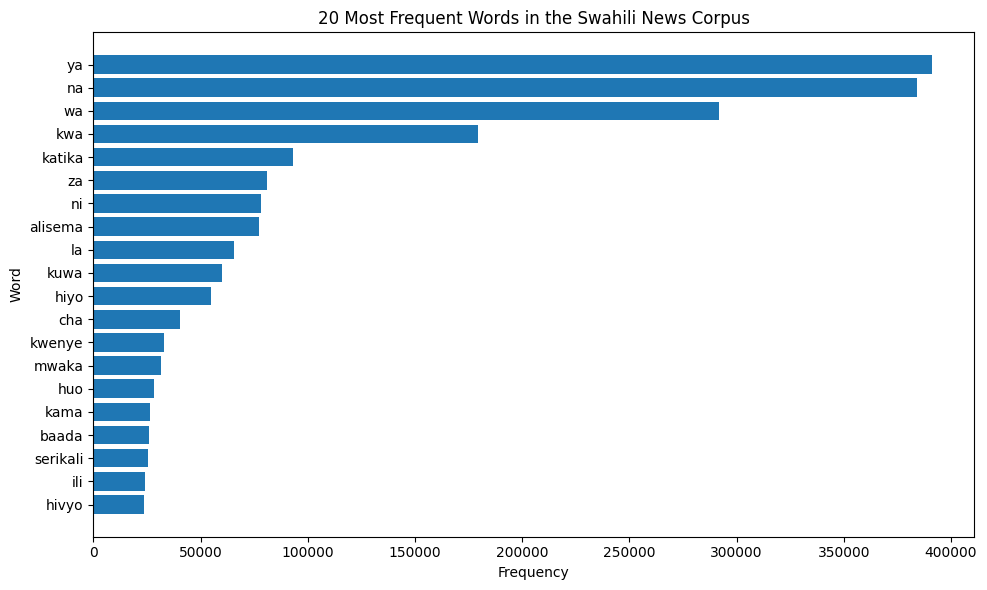

In [ ]:
top20 = common_words.head(20)

plt.figure(figsize=(10, 6))

plt.barh(
    top20["word"][::-1],
    top20["frequency"][::-1]
)

plt.title("20 Most Frequent Words in the Swahili News Corpus")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.tight_layout()
plt.show()

In [ ]:
rare_examples = [
    word for word, count in word_counts.items()
    if count == 1
]

print("Example words appearing only once:")
print(rare_examples[:50])

Example words appearing only once:
['nanjig', 'kuitengua', 'itengua', 'iliziondoa', 'viga', 'zinazonitaka', 'lisihusishwe', 'kusihesabiwe', 'msivunjike', 'msirumbane', 'heshimianeni', 'shikamaneni', 'iwaelekeze', 'michela', 'awaasa', 'amewaoa', 'aliyoiongoza', 'zinamwelezea', 'kiliachwa', 'akapandishwa', 'vilivyojaribu', 'lukaya', 'yanapowafika', 'limeziba', 'tunaukaribisha', 'minhai', 'wanavyouza', 'vikiikosoa', 'walimshinikiza', 'angetumikia', 'alikoonana', 'addax', 'yameshajadiliwa', 'vinavyokubaliwa', 'unafanikishwa', 'litavutia', 'wanaowakabidhi', 'mnawekeza', 'mnawakabidhi', 'wasaideni', 'mtavisajili', 'mnazofanyia', 'essore', 'amewaonyesha', 'aombewe', 'inafedhehesha', 'wanaowanyima', 'watatusamahe', 'walilikosa', 'jumhuri']


### Vocabulary Sparsity and Modelling Implications

The exploratory vocabulary contains **201,361 unique words**, indicating substantial lexical diversity within the corpus. More importantly, the vocabulary exhibits a strong long-tail distribution.

Of all unique words, **103,678 (51.49%) occur only once**, while **161,708 (80.31%) occur five times or fewer**. Therefore, the majority of unique word forms are represented by very few observations.

This sparsity has important implications for word-level sequential models. Allocating independent learned embeddings to every observed word would produce a very large vocabulary in which many representations receive insufficient training evidence. A restricted word-level vocabulary with an out-of-vocabulary representation may therefore be more appropriate.

The high proportion of rare words also provides motivation for investigating subword-based representations. Unlike a strictly word-level vocabulary, subword tokenization can represent uncommon or previously unseen words through smaller recurring units. However, the effectiveness of this approach must ultimately be determined experimentally rather than assumed from the exploratory analysis.

After the dataset is split, out-of-vocabulary rates will also be measured on the validation and test sets to determine how frequently the models encounter lexical items not observed during training.

## 9. Text Noise and Quality Analysis

Raw news text may contain formatting artifacts or non-linguistic elements that affect tokenization and model input. Before defining the preprocessing pipeline, the corpus is examined for URLs, numerical content, excessive whitespace, line breaks, HTML-like markup, and unusually short articles.

The objective is not to remove every irregular feature automatically, but to determine which characteristics are sufficiently common to justify preprocessing and which may contain useful information for news classification.

In [ ]:
import re
import pandas as pd

def contains_url(text):
    return bool(re.search(r'https?://|www\.', str(text), flags=re.IGNORECASE))

def contains_digit(text):
    return bool(re.search(r'\d', str(text)))

def contains_html(text):
    return bool(re.search(r'<[^>]+>', str(text)))

def contains_multiple_spaces(text):
    return bool(re.search(r' {2,}', str(text)))

def contains_newline(text):
    return '\n' in str(text)

noise_summary = pd.DataFrame({
    "feature": [
        "Contains URL",
        "Contains digits",
        "Contains HTML-like tags",
        "Contains multiple spaces",
        "Contains newline characters"
    ],
    "articles": [
        df["content"].apply(contains_url).sum(),
        df["content"].apply(contains_digit).sum(),
        df["content"].apply(contains_html).sum(),
        df["content"].apply(contains_multiple_spaces).sum(),
        df["content"].apply(contains_newline).sum()
    ]
})

noise_summary["percentage"] = (
    noise_summary["articles"] / len(df) * 100
).round(2)

display(noise_summary)

,feature,articles,percentage
0,Contains URL,113,0.49
1,Contains digits,19547,84.01
2,Contains HTML-like tags,0,0.00
3,Contains multiple spaces,3918,16.84
4,Contains newline characters,4486,19.28


In [ ]:
print("VERY SHORT ARTICLE ANALYSIS")
print("=" * 45)

for threshold in [0, 5, 10, 20, 50]:
    count = (df["word_count"] <= threshold).sum()
    percentage = count / len(df) * 100

    print(
        f"Articles with <= {threshold:2d} words: "
        f"{count:4d} ({percentage:.2f}%)"
    )

VERY SHORT ARTICLE ANALYSIS
Articles with <=  0 words:    1 (0.00%)
Articles with <=  5 words:    2 (0.01%)
Articles with <= 10 words:    2 (0.01%)
Articles with <= 20 words:    2 (0.01%)
Articles with <= 50 words:   25 (0.11%)


In [ ]:
shortest_articles = (
    df[["id", "category", "content", "word_count"]]
    .sort_values("word_count")
    .head(15)
)

display(shortest_articles)

,id,category,content,word_count
13247,SW13408,uchumi,,0
19836,SW30398,michezo,['.'],1
17334,SW9151,michezo,Mao alijiunga na Petrojet Juni mwaka jana akit...,22
1961,SW20620,michezo,Mchezaji wa timu ya yanga mwenye nambali 16 ka...,25
16107,SW9585,michezo,Amunike alifutwa kazi na Shirikisho la Mpira w...,26
15312,SW12329,burudani,Unaweza kusema virusi vya Corona sasa vimeiand...,26
21074,SW7546,michezo,Mechi hiyo inatarajiwa kuchezwa kwenye uwanja...,28
19621,SW29737,burudani,Shirikisho la soka duniani (Fifa) limempa zawa...,30
6448,SW13608,burudani,.Wizkid ameshinda tuzo kubwa za Marekani za So...,30
5228,SW15512,uchumi,.https://www.youtube.com/watch?v=IIhWNE4aspw&f...,31


In [ ]:
url_mask = df["content"].apply(contains_url)

print("Articles containing URLs:", url_mask.sum())

if url_mask.sum() > 0:
    display(
        df.loc[url_mask, ["id", "category", "content"]]
        .head(10)
    )

Articles containing URLs: 113


,id,category,content
169,SW18649,burudani,\nIkiwa imebakia takribani miezi minne kueleka...
302,SW23610,uchumi,"“Hatua hii ya Brela ni nzuri, wanastahili pon..."
440,SW8389,kitaifa,BODI ya Mikopo ya Wanafunzi wa Elimu ya Juu (...
455,SW1087,kitaifa,"WAZIRI wa Michezo wa Kenya, Amina Mohamed ana..."
516,SW17769,kitaifa,MAMLAKA ya Mapato Tanzania (TRA) imekanusha h...
1581,SW11511,afya,"\n\n \n\t \n \n\t \n \nNa Christian Bwaya,\n \..."
1744,SW4500,uchumi,Wadau katika mtandao wa Twitter wamechachamaa...
1829,SW22943,michezo,Usiku wa kuamkia jana haikuwa siku nzuri sana ...
2212,SW17700,burudani,Unaukumbuka wimbo wa Fm Aacemia kuhusu Jela? M...
2312,SW7625,burudani,Ati Wakanyagwe! Msanii na video vixen Amber Lu...


In [ ]:
digit_mask = df["content"].apply(contains_digit)

print(
    f"Articles containing digits: "
    f"{digit_mask.sum():,} "
    f"({digit_mask.mean() * 100:.2f}%)"
)

Articles containing digits: 19,547 (84.01%)


In [ ]:
formatting_stats = {
    "Articles containing newline": df["content"]
        .str.contains("\n", regex=False).sum(),

    "Articles containing tab": df["content"]
        .str.contains("\t", regex=False).sum(),

    "Articles containing repeated spaces": df["content"]
        .str.contains(r" {2,}", regex=True).sum()
}

for feature, count in formatting_stats.items():
    print(
        f"{feature}: {count:,} "
        f"({count / len(df) * 100:.2f}%)"
    )

Articles containing newline: 4,486 (19.28%)
Articles containing tab: 1,304 (5.60%)
Articles containing repeated spaces: 3,918 (16.84%)


### Text Quality Findings and Preprocessing Implications

The text-quality analysis revealed that most irregularities are related to formatting rather than missing linguistic content. Newline characters occur in 19.28% of articles, repeated spaces in 16.84%, and tab characters in 5.60%. These formatting artifacts can be normalized into single spaces without removing meaningful textual information.

Numerical content is extremely common: 19,547 articles (84.01%) contain at least one digit. Numbers may represent dates, monetary values, percentages, sports scores, or other information relevant to news categories. Consequently, digits will not be removed automatically during preprocessing.

URLs occur in only 113 articles (0.49%). Because complete URLs may introduce highly specific and sparse tokens, they can be normalized to a common URL representation rather than allowing each address to contribute many unique vocabulary items. No HTML-like tags were detected, so HTML removal is unnecessary for this dataset.

Analysis of unusually short documents identified two clearly unusable observations: one article contains no words, while another contains only `['.']`. The next shortest article contains 22 words and appears to contain meaningful news content. Therefore, only the two clearly non-informative observations will be removed on the basis of document length rather than applying an arbitrary minimum-length threshold.

Overall, preprocessing will be deliberately conservative. The objective is to normalize obvious formatting artifacts while preserving potentially meaningful linguistic and numerical information for the sequential models.

## 10. Data Cleaning and Preparation

Based on the exploratory analysis, a conservative cleaning strategy was adopted. The objective is to remove clear data-quality problems and reduce leakage risk while preserving potentially useful linguistic information.

The cleaning process therefore focuses on:

1. removing non-informative documents;
2. normalizing URLs and irregular whitespace;
3. removing exact same-label duplicate articles;
4. treating conflicting-label articles separately rather than arbitrarily assigning them a category.

Numbers, common Swahili words, and meaningful short articles are retained because the exploratory analysis did not provide sufficient evidence that removing them would improve the classification task.

In [ ]:
import re
import pandas as pd

def clean_text(text):
    text = str(text)

    # Replace URLs with a common token
    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' URL ',
        text,
        flags=re.IGNORECASE
    )

    # Normalize tabs, newlines and repeated whitespace
    text = re.sub(r'\s+', ' ', text)

    # Remove leading/trailing whitespace
    text = text.strip()

    return text

In [ ]:
df_clean = df.copy()

df_clean["clean_content"] = (
    df_clean["content"]
    .apply(clean_text)
)

print("Original records:", len(df_clean))

Original records: 23268


In [ ]:
for i in [0, 1, 2]:

    print("=" * 100)

    print("ORIGINAL:")
    print(repr(df_clean.loc[i, "content"][:300]))

    print("\nCLEANED:")
    print(repr(df_clean.loc[i, "clean_content"][:300]))

    print()

ORIGINAL:
' Bodi ya Utalii Tanzania (TTB) imesema, itafanya misafara ya kutangaza utalii kwenye miji minne nchini China kati ya Juni 19 hadi Juni 26 mwaka huu.Misafara hiyo itatembelea miji ya Beijing Juni 19, Shanghai Juni 21, Nanjig Juni 24 na Changsha Juni 26.Mwenyekiti wa bodi TTB, Jaji Mstaafu Thomas Miha'

CLEANED:
'Bodi ya Utalii Tanzania (TTB) imesema, itafanya misafara ya kutangaza utalii kwenye miji minne nchini China kati ya Juni 19 hadi Juni 26 mwaka huu.Misafara hiyo itatembelea miji ya Beijing Juni 19, Shanghai Juni 21, Nanjig Juni 24 na Changsha Juni 26.Mwenyekiti wa bodi TTB, Jaji Mstaafu Thomas Mihay'

ORIGINAL:
' PENDO FUNDISHA-MBEYA RAIS Dk. John Magufuri, ametangaza kuwafukuza\nkazi wakurugenzi wote wa halmashauri ambao watabainika kukiuka sheria ya\nufutaji wa tozo za ushuru wa mazao. Alisema baada ya kuingia madarakani, Serikali\niliondoa tozo 80, miongoni mwa hizo tozo ushuru wakulima ambao walikuwa\nwakil'

CLEANED:
'PENDO FUNDISHA-MBEYA RAIS Dk. John Magufuri, 

In [ ]:
import re

# Make a copy of the original dataset
df_clean = df.copy()

# ------------------------------------------
# 1. Clean text
# ------------------------------------------

def clean_text(text):
    text = str(text)

    # Replace URLs with a common token
    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' URL ',
        text,
        flags=re.IGNORECASE
    )

    # Normalize newlines, tabs and repeated spaces
    text = re.sub(r'\s+', ' ', text)

    # Remove leading/trailing whitespace
    text = text.strip()

    return text


df_clean["clean_content"] = df_clean["content"].apply(clean_text)


# ------------------------------------------
# 2. Identify informative documents
# ------------------------------------------

def contains_letters(text):
    return bool(
        re.search(r'[^\W\d_]', str(text), flags=re.UNICODE)
    )


informative_mask = df_clean["clean_content"].apply(contains_letters)

print("BEFORE REMOVAL")
print("=" * 40)
print("Original records:", len(df_clean))
print("Informative documents:", informative_mask.sum())
print("Non-informative documents:", (~informative_mask).sum())


# Show what will be removed
print("\nDocuments identified as non-informative:")

display(
    df_clean.loc[
        ~informative_mask,
        ["id", "category", "content", "clean_content"]
    ]
)


# ------------------------------------------
# 3. Remove non-informative documents
# ------------------------------------------

df_clean = (
    df_clean[informative_mask]
    .copy()
    .reset_index(drop=True)
)

print("\nAFTER REMOVAL")
print("=" * 40)
print("Records remaining:", len(df_clean))


# ------------------------------------------
# 4. Recheck duplicates after normalization
# ------------------------------------------

duplicate_cleaned = df_clean["clean_content"].duplicated().sum()

clean_label_counts = (
    df_clean.groupby("clean_content")["category"].nunique()
)

clean_conflicting_texts = clean_label_counts[
    clean_label_counts > 1
].index

print("\nDUPLICATE CHECK AFTER NORMALIZATION")
print("=" * 40)

print("Duplicate cleaned article rows:", duplicate_cleaned)

print(
    "Unique cleaned articles with conflicting labels:",
    len(clean_conflicting_texts)
)

BEFORE REMOVAL
Original records: 23268
Informative documents: 23266
Non-informative documents: 2

Documents identified as non-informative:


,id,category,content,clean_content
13247,SW13408,uchumi,,
19836,SW30398,michezo,['.'],['.']



AFTER REMOVAL
Records remaining: 23266

DUPLICATE CHECK AFTER NORMALIZATION
Duplicate cleaned article rows: 1068
Unique cleaned articles with conflicting labels: 271


### Cleaning Results

Text normalization successfully removed irregular leading/trailing whitespace, line breaks, tabs, and repeated spaces while preserving the linguistic content of the articles. URLs were standardized rather than deleted, while numbers and ordinary punctuation were retained.

Two non-informative documents were identified and removed: one empty article and one observation containing only punctuation-like content. This reduced the dataset from **23,268 to 23,266 usable observations**.

After text normalization, the number of duplicate article rows increased from 1,061 to **1,068**. This indicates that seven additional duplicates had previously been obscured by superficial formatting differences. Normalizing the text therefore improved duplicate detection.

The number of unique article texts associated with conflicting labels remained **271**, indicating that these label conflicts cannot be explained simply by whitespace or formatting differences.

In [ ]:
# ==========================================
# SEPARATE CONFLICTING AND UNAMBIGUOUS DATA
# ==========================================

# Identify conflicting article texts
label_counts = (
    df_clean
    .groupby("clean_content")["category"]
    .nunique()
)

conflicting_texts = label_counts[
    label_counts > 1
].index


# Separate conflicting rows
df_conflicts = df_clean[
    df_clean["clean_content"].isin(conflicting_texts)
].copy()


# Separate unambiguous rows
df_unambiguous = df_clean[
    ~df_clean["clean_content"].isin(conflicting_texts)
].copy()


print("Rows before separation:", len(df_clean))
print("Unambiguous rows:", len(df_unambiguous))
print("Conflicting rows:", len(df_conflicts))
print("Unique conflicting texts:", df_conflicts["clean_content"].nunique())

Rows before separation: 23266
Unambiguous rows: 22636
Conflicting rows: 630
Unique conflicting texts: 271


In [ ]:
# Number before deduplication
before_dedup = len(df_unambiguous)

# Keep one copy of each unambiguous article
df_unambiguous = (
    df_unambiguous
    .drop_duplicates(
        subset=["clean_content", "category"],
        keep="first"
    )
    .reset_index(drop=True)
)

after_dedup = len(df_unambiguous)

print("Before same-label deduplication:", before_dedup)
print("After same-label deduplication:", after_dedup)
print("Same-label duplicate rows removed:", before_dedup - after_dedup)

Before same-label deduplication: 22636
After same-label deduplication: 21927
Same-label duplicate rows removed: 709


In [ ]:
print("Class distribution after removing same-label duplicates:")
print(df_unambiguous["category"].value_counts())

print("\nClass percentages:")
print(
    (
        df_unambiguous["category"]
        .value_counts(normalize=True)
        * 100
    ).round(2)
)

Class distribution after removing same-label duplicates:
category
kitaifa      10061
michezo       5948
burudani      2143
kimataifa     1816
uchumi        1257
afya           702
Name: count, dtype: int64

Class percentages:
category
kitaifa      45.88
michezo      27.13
burudani      9.77
kimataifa     8.28
uchumi        5.73
afya          3.20
Name: proportion, dtype: float64


23,268 original rows
        ↓
Remove 2 non-informative documents
        ↓
23,266
        ↓
Separate 630 rows involved in label conflicts
        ↓
22,636 unambiguous rows
        ↓
Remove 709 same-label duplicate rows
        ↓
21,927 modelling examples

### Final Deduplication Results

After separating the 630 rows associated with conflicting labels, 22,636 unambiguous observations remained. Exact same-label duplicates were then removed from this subset, eliminating a further 709 repeated observations and producing a primary modelling dataset of **21,927 unique, unambiguous news articles**.

The cleaning process affected the categories differently. `Kitaifa` remains the largest category with 10,061 observations (45.88%), while `afya` contains only 702 observations (3.20%). The resulting modelling dataset therefore remains substantially class-imbalanced.

A particularly notable change occurred in the `uchumi` category, which decreased from 2,028 observations in the original dataset to 1,257 unique, unambiguous observations. Since only 82 `uchumi` rows were previously identified as participating in label conflicts, much of this reduction appears to result from repeated same-label content. This suggests that duplicate prevalence differs considerably across categories.

The cleaning process therefore improves the independence of observations and reduces the risk of duplicate-based data leakage, but it does not resolve the underlying class imbalance. Evaluation will consequently emphasize macro-averaged and per-class metrics in addition to overall accuracy.

The 630 conflicting rows are retained separately rather than discarded permanently. This preserves the ambiguous cases for later investigation while preventing conflicting supervision from affecting the primary model comparison.

In [ ]:
# Work only with unambiguous data before deduplication
unambiguous_before_dedup = df_clean[
    ~df_clean["clean_content"].isin(conflicting_texts)
].copy()

# Identify duplicate copies beyond the first occurrence
same_label_duplicate_mask = (
    unambiguous_before_dedup
    .duplicated(
        subset=["clean_content", "category"],
        keep="first"
    )
)

duplicate_rows_by_class = (
    unambiguous_before_dedup.loc[
        same_label_duplicate_mask,
        "category"
    ]
    .value_counts()
)

print("Same-label duplicate rows removed by category:")
print(duplicate_rows_by_class)

Same-label duplicate rows removed by category:
category
uchumi       688
michezo        8
kimataifa      4
kitaifa        4
burudani       3
afya           2
Name: count, dtype: int64


### Category-Specific Duplicate Analysis

Further analysis revealed that same-label duplication was highly concentrated in the `uchumi` category. Of the **709 same-label duplicate rows removed, 688 (approximately 97%) belonged to `uchumi`**. In comparison, only eight duplicate rows were removed from `michezo`, four each from `kimataifa` and `kitaifa`, three from `burudani`, and two from `afya`.

This explains the substantial reduction in `uchumi` observations from 2,028 articles in the original dataset to 1,257 unique, unambiguous articles in the final modelling dataset.

This finding also reinforces the importance of performing deduplication before the train-validation-test split. If identical `uchumi` articles had been randomly distributed across training and evaluation sets, a model could be evaluated on articles it had effectively already encountered during training, potentially producing an overly optimistic estimate of generalization performance.

The final modelling dataset therefore contains one copy of each unambiguous article, providing a stricter basis for comparing the models on previously unseen news content.

Training
    ↓
Used to learn model parameters

Validation
    ↓
Used to compare experiments,
hyperparameters and model choices

Test
    ↓
Used ONCE for final evaluation

## 11. Train, Validation and Test Split

The cleaned dataset was divided into separate training, validation, and test sets using a **70:15:15 split**.

The training set is used to learn model parameters, while the validation set is used during experimentation and model selection. The test set is reserved for final evaluation and is not used to make modelling or hyperparameter decisions.

Because the dataset is substantially class-imbalanced, stratified splitting is used to preserve approximately the same category distribution across all three subsets. A fixed random seed is also used to ensure that the split can be reproduced.

In [ ]:
from sklearn.model_selection import train_test_split

SEED = 42

# First split: 70% training, 30% temporary
train_df, temp_df = train_test_split(
    df_unambiguous,
    test_size=0.30,
    random_state=SEED,
    stratify=df_unambiguous["category"]
)

# Second split:
# divide the remaining 30% equally into validation and test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["category"]
)

print("DATASET SPLIT")
print("=" * 40)

print(f"Training:   {len(train_df):,} ({len(train_df)/len(df_unambiguous)*100:.2f}%)")
print(f"Validation: {len(val_df):,} ({len(val_df)/len(df_unambiguous)*100:.2f}%)")
print(f"Test:       {len(test_df):,} ({len(test_df)/len(df_unambiguous)*100:.2f}%)")

print("\nTotal:", len(train_df) + len(val_df) + len(test_df))

DATASET SPLIT
Training:   15,348 (70.00%)
Validation: 3,289 (15.00%)
Test:       3,290 (15.00%)

Total: 21927


In [ ]:
split_distribution = pd.DataFrame({
    "Full Dataset": (
        df_unambiguous["category"]
        .value_counts(normalize=True) * 100
    ),

    "Train": (
        train_df["category"]
        .value_counts(normalize=True) * 100
    ),

    "Validation": (
        val_df["category"]
        .value_counts(normalize=True) * 100
    ),

    "Test": (
        test_df["category"]
        .value_counts(normalize=True) * 100
    )
}).round(2)

display(split_distribution)

,Full Dataset,Train,Validation,Test
category,,,,
kitaifa,45.88,45.88,45.88,45.90
michezo,27.13,27.12,27.12,27.14
burudani,9.77,9.77,9.76,9.79
kimataifa,8.28,8.28,8.30,8.27
uchumi,5.73,5.73,5.75,5.71
afya,3.20,3.21,3.19,3.19


In [ ]:
train_texts = set(train_df["clean_content"])
val_texts = set(val_df["clean_content"])
test_texts = set(test_df["clean_content"])

print("LEAKAGE CHECK")
print("=" * 40)

print(
    "Train ↔ Validation overlap:",
    len(train_texts.intersection(val_texts))
)

print(
    "Train ↔ Test overlap:",
    len(train_texts.intersection(test_texts))
)

print(
    "Validation ↔ Test overlap:",
    len(val_texts.intersection(test_texts))
)

LEAKAGE CHECK
Train ↔ Validation overlap: 0
Train ↔ Test overlap: 0
Validation ↔ Test overlap: 0


### Split Validation and Leakage Check

The final modelling dataset of 21,927 articles was successfully divided into **15,348 training observations (70%)**, **3,289 validation observations (15%)**, and **3,290 test observations (15%)**.

Stratification preserved the original class distribution with very little variation between subsets. For example, `kitaifa` represents 45.88% of the complete modelling dataset and 45.88%, 45.88%, and 45.90% of the training, validation, and test sets respectively. Similarly, the minority `afya` class remains approximately 3.2% across all subsets.

An explicit leakage check found **zero overlapping article texts** between the training and validation sets, training and test sets, and validation and test sets. This confirms that exact duplicate articles do not cross evaluation boundaries.

The training set will therefore be used for model fitting, the validation set for experimental comparison and model-selection decisions, and the test set will remain untouched until the final models have been selected.

## From Exploratory Analysis to Modelling Decisions

The exploratory analysis directly informed the experimental design rather than being treated as a separate descriptive exercise.

| EDA finding | Evidence from this dataset | Modelling or evaluation decision |
|---|---:|---|
| Strong class imbalance | `kitaifa` **45.88%** vs `afya` **3.20%** after cleaning | Use **macro-F1** as the primary selection metric; inspect per-class precision/recall/F1; apply class weighting to task-specific neural models. |
| Large long-tail vocabulary | **201,361** word forms; **51.49%** occur once and **80.31%** occur five times or fewer | Compare sparse TF-IDF and restricted word-level neural vocabularies with XLM-R's **subword** representation. |
| Duplicate texts | **709** same-label duplicate rows removed from the unambiguous data | Deduplicate before splitting so repeated articles cannot make evaluation artificially easy. |
| Conflicting labels | **271** unique texts, involving **630** rows, appeared with multiple labels | Exclude conflicting texts from modelling so identical content does not provide contradictory supervision or cross split boundaries. |
| Long and variable article lengths | Median **276** words; 95th percentile **784** words before modelling | Use a longer sequence window for BiLSTM/CNN (`MAX_LENGTH=600`); use a shorter XLM-R window because Transformer memory cost made longer contexts impractical in the available environment. |
| Exact-text leakage risk | Duplicate analysis showed repeated content before cleaning | Perform an explicit post-split overlap check; the final split had **0** exact-text overlap between train, validation and test. |

These links are important to the experimental logic: preprocessing, representation and evaluation choices were responses to measured properties of the corpus rather than arbitrary defaults.


## 12. Evaluation Strategy

Model performance is evaluated using multiple classification metrics rather than accuracy alone. This is necessary because the cleaned dataset remains substantially imbalanced: `kitaifa` represents approximately 45.9% of observations, while `afya` represents only approximately 3.2%.

The following metrics are considered:

- **Accuracy:** the overall proportion of correctly classified articles.
- **Precision:** how often predictions for a particular category are correct.
- **Recall:** how many articles belonging to a category are successfully identified.
- **F1-score:** the harmonic mean of precision and recall.
- **Macro-F1:** F1 is calculated independently for every category and then averaged, giving each category equal importance regardless of frequency.
- **Weighted-F1:** class F1-scores are averaged while weighting each class by its support.

Because of the substantial class imbalance identified during exploratory analysis, **macro-F1 is the primary model-selection metric**. Accuracy and weighted-F1 are complementary overall measures, while per-class precision, recall, and F1 are used to examine behaviour on individual categories, particularly minority classes such as `afya` and `uchumi`. This prevents strong performance on the dominant `kitaifa` class from masking weak performance on smaller categories.

Confusion matrices are also used to identify systematic category confusion. This is particularly important because the exploratory analysis identified overlapping and conflicting labels, especially around `afya` and `kitaifa`.

The evaluation design therefore combines an aggregate metric (macro-F1), overall performance measures (accuracy and weighted-F1), and class-level/error analysis. The held-out test set is reserved for final evaluation and is not used for model or hyperparameter selection.

### Why Macro-F1 Is the Primary Metric

The imbalance is large enough that a single overall score can hide important failures. After cleaning, `kitaifa` accounts for **45.88%** of the modelling data, whereas `afya` accounts for only **3.20%**. A classifier can therefore obtain a relatively high accuracy by favouring common categories while still performing poorly on the smallest classes. **Macro-F1** addresses this by calculating F1 separately for each class and giving all six classes equal weight. This makes it the most appropriate primary metric for comparing models in this study.

Accuracy and weighted-F1 are retained because they answer complementary questions. Accuracy measures the overall proportion of correct predictions, while weighted-F1 reflects class-level F1 in proportion to class support. Their limitation in this dataset is that performance on `kitaifa` and `michezo` has a much larger influence than performance on `afya` or `uchumi`. Macro-F1 has the opposite trade-off: a small class contributes as much as a large class, so a relatively small number of minority-class predictions can noticeably change the score. For this reason, no model is judged from macro-F1 alone; **per-class precision, recall and F1, confusion matrices, and manual error inspection** are used to determine where the aggregate score comes from. This use of class-sensitive metrics follows the broader recommendation that evaluation under class imbalance should not rely only on accuracy (Sokolova & Lapalme, 2009).


## 13. Baseline Performance

Before training machine-learning and sequential models, a majority-class baseline is established. This classifier ignores the article text and predicts the most frequent training category for every validation observation.

The purpose of this baseline is not to provide a competitive solution, but to establish a minimum reference point against which learned models can be compared.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

# Find majority class using TRAINING DATA ONLY
majority_class = train_df["category"].mode()[0]

# Predict that class for every validation article
majority_predictions = [majority_class] * len(val_df)

majority_accuracy = accuracy_score(
    val_df["category"],
    majority_predictions
)

majority_macro_f1 = f1_score(
    val_df["category"],
    majority_predictions,
    average="macro"
)

majority_weighted_f1 = f1_score(
    val_df["category"],
    majority_predictions,
    average="weighted"
)

print("MAJORITY-CLASS BASELINE")
print("=" * 45)

print("Majority class:", majority_class)
print(f"Validation Accuracy:    {majority_accuracy:.4f}")
print(f"Validation Macro-F1:    {majority_macro_f1:.4f}")
print(f"Validation Weighted-F1: {majority_weighted_f1:.4f}")

MAJORITY-CLASS BASELINE
Majority class: kitaifa
Validation Accuracy:    0.4588
Validation Macro-F1:    0.1048
Validation Weighted-F1: 0.2886


## Experimental Progression and Research Logic

The experiments were designed as a progression from a non-learning reference point to increasingly expressive text representations. Each stage answers a different question about what is necessary for this classification task.

| Stage | Approach | Key validation evidence | What the experiment established |
|---|---|---:|---|
| 1 | Majority-class baseline | Macro-F1 **0.1048** | A trivial strategy performs poorly across classes despite the dominance of `kitaifa`; class-sensitive evaluation is necessary. |
| 2 | TF-IDF + Logistic Regression | Macro-F1 **0.7532** | Weighted lexical occurrence alone captures substantial category information. |
| 3 | TF-IDF + Linear SVM | Macro-F1 **0.7818** | A margin-based sparse classifier improves the classical baseline and provides a strong benchmark for neural models. |
| 4 | BiLSTM | Macro-F1 **0.8030** | Bidirectional sequential modelling provides a modest improvement over SVM, but not a dramatic one. |
| 5 | 1D CNN | Macro-F1 **0.7894** | Learned local sequential patterns are competitive, but do not clearly surpass BiLSTM or the strong SVM baseline. |
| 6 | XLM-R | Macro-F1 **0.8713** | The largest improvement appears when contextual sequence modelling is combined with multilingual pretraining and subword tokenization. |

This progression prevents the final XLM-R score from being interpreted in isolation. The classical models show that the dataset contains strong lexical signals, while the BiLSTM and CNN show that simply replacing TF-IDF with task-trained neural sequence representations does not guarantee a large gain. XLM-R's improvement therefore points to the value of **contextual multilingual pretraining and subword representation**, while the experiment cannot isolate Transformer architecture from the benefit of pretraining.


### Majority-Baseline Results

The majority-class baseline identified `kitaifa` as the most frequent category in the training data and predicted this category for every validation observation.

Despite performing no text analysis, the baseline achieved an accuracy of **45.88%**. This relatively high accuracy results directly from the class imbalance, as approximately 45.9% of the validation observations belong to `kitaifa`.

However, its **macro-F1 score was only 0.1048**, while its weighted-F1 was 0.2886. The large difference between accuracy and macro-F1 demonstrates that accuracy alone provides an incomplete representation of performance for this dataset. The majority classifier achieves reasonable accuracy while completely failing to identify the five minority categories.

This result provides empirical support for using **macro-F1 as the primary metric during model selection**, alongside accuracy, weighted-F1, and per-class evaluation.

The majority baseline therefore establishes a minimum reference point of **0.1048 validation macro-F1**. Subsequent models should substantially outperform this baseline by learning useful information from the article text and correctly identifying multiple news categories.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

# ------------------------------------------
# TF-IDF representation
# ------------------------------------------

tfidf = TfidfVectorizer(
    lowercase=True,
    max_features=40000,
    ngram_range=(1, 1),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(
    train_df["clean_content"]
)

X_val_tfidf = tfidf.transform(
    val_df["clean_content"]
)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF validation shape:", X_val_tfidf.shape)


# ------------------------------------------
# Logistic Regression
# ------------------------------------------

logreg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logreg.fit(
    X_train_tfidf,
    train_df["category"]
)


# ------------------------------------------
# Validation predictions
# ------------------------------------------

val_predictions = logreg.predict(X_val_tfidf)


# ------------------------------------------
# Evaluation
# ------------------------------------------

accuracy = accuracy_score(
    val_df["category"],
    val_predictions
)

macro_f1 = f1_score(
    val_df["category"],
    val_predictions,
    average="macro"
)

weighted_f1 = f1_score(
    val_df["category"],
    val_predictions,
    average="weighted"
)

print("\nTF-IDF + LOGISTIC REGRESSION")
print("=" * 45)

print(f"Validation Accuracy:    {accuracy:.4f}")
print(f"Validation Macro-F1:    {macro_f1:.4f}")
print(f"Validation Weighted-F1: {weighted_f1:.4f}")

TF-IDF training shape: (15348, 40000)
TF-IDF validation shape: (3289, 40000)

TF-IDF + LOGISTIC REGRESSION
Validation Accuracy:    0.8729
Validation Macro-F1:    0.7532
Validation Weighted-F1: 0.8643


### TF-IDF + Logistic Regression Results

The TF-IDF Logistic Regression baseline substantially outperformed the majority-class baseline. It achieved a validation accuracy of **0.8729**, macro-F1 of **0.7532**, and weighted-F1 of **0.8643**, compared with a macro-F1 of only 0.1048 for the majority classifier.

This result demonstrates that the lexical content of the articles contains strong information for distinguishing the six news categories. A conventional bag-of-words-based representation can therefore solve a substantial part of the classification problem without explicitly modelling token order or long-range sequential dependencies.

However, the difference between accuracy (0.8729) and macro-F1 (0.7532) also indicates that overall performance does not fully describe behaviour across the imbalanced classes. Per-class evaluation is therefore required, particularly for the minority `afya` category.

The strong TF-IDF baseline creates a demanding reference point for the sequential models. Subsequent experiments will investigate whether architectures that explicitly learn sequential and contextual relationships can improve performance beyond lexical term-frequency information alone.

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        val_df["category"],
        val_predictions,
        digits=4
    )
)

              precision    recall  f1-score   support

        afya     0.6977    0.2857    0.4054       105
    burudani     0.8869    0.9034    0.8951       321
   kimataifa     0.8992    0.8168    0.8560       273
     kitaifa     0.8369    0.9417    0.8862      1509
     michezo     0.9594    0.9271    0.9430       892
      uchumi     0.7207    0.4233    0.5333       189

    accuracy                         0.8729      3289
   macro avg     0.8335    0.7163    0.7532      3289
weighted avg     0.8690    0.8729    0.8643      3289



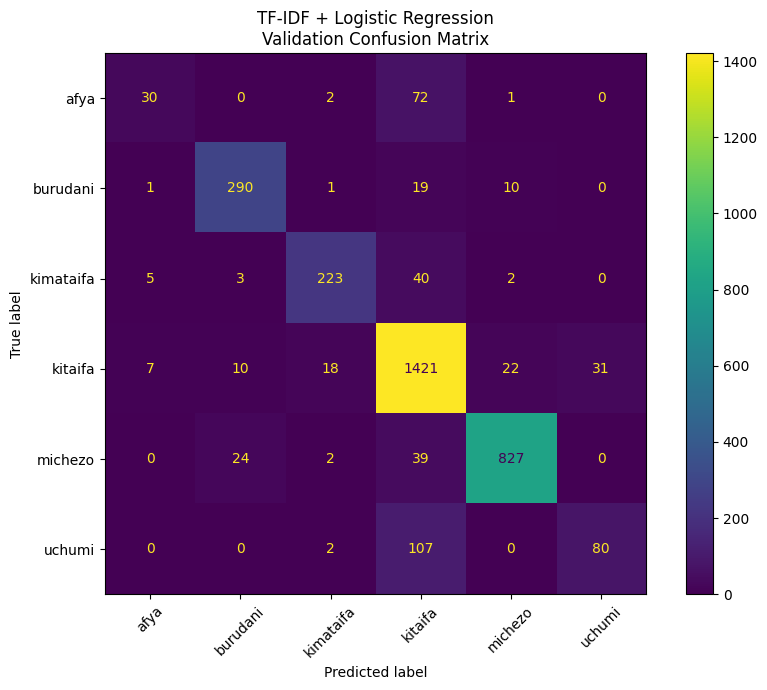

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = sorted(train_df["category"].unique())

cm = confusion_matrix(
    val_df["category"],
    val_predictions,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(9, 7))

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title(
    "TF-IDF + Logistic Regression\nValidation Confusion Matrix"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Per-Class Performance and Error Patterns

Although TF-IDF with Logistic Regression achieved a strong overall accuracy of **0.8729**, per-class evaluation revealed substantial differences in performance.

The strongest performance was observed for `michezo`, which achieved an F1-score of **0.9430**, followed by `burudani` (0.8951), `kitaifa` (0.8862), and `kimataifa` (0.8560). In contrast, performance was considerably weaker for the minority `afya` and `uchumi` categories, with F1-scores of **0.4054** and **0.5333**, respectively.

The confusion matrix reveals a particularly strong tendency for these minority categories to be predicted as `kitaifa`. Of the 105 validation articles belonging to `afya`, only 30 were classified correctly, while **72 (68.6%) were predicted as `kitaifa`**. This pattern is consistent with the exploratory analysis, which identified `afya`–`kitaifa` as the most frequent conflicting-label pair in the original data, involving 134 unique article texts. Although this does not establish that label ambiguity caused the validation errors, it indicates that distinguishing these categories may be intrinsically challenging within this dataset.

A similar pattern was observed for `uchumi`. Of 189 validation observations, 80 were correctly classified while **107 (56.6%) were predicted as `kitaifa`**. Earlier data-quality analysis also showed that `uchumi` contained unusually high same-label duplication, with 688 duplicate rows removed before splitting. Consequently, the number of unique `uchumi` training examples is substantially smaller than the original class frequency suggested.

More broadly, many errors across categories were assigned to `kitaifa`, the dominant class representing approximately 45.9% of the modelling dataset. This may reflect a combination of class imbalance and lexical or thematic overlap between national news and more specialized categories.

These findings demonstrate why overall accuracy alone is insufficient. Subsequent sequential models will therefore be evaluated not only on overall macro-F1, but also on whether they improve recall and F1 for difficult minority categories such as `afya` and `uchumi`.

## 16. Related Work and Model Selection

Text classification can be approached using representations that range from sparse lexical features to contextual neural representations. The models in this study were selected to compare these substantially different assumptions rather than to test small variations of one architecture.

**Recurrent sequence modelling.** Long Short-Term Memory (LSTM) networks were introduced by Hochreiter and Schmidhuber (1997) to address difficulties in learning long-range dependencies with recurrent neural networks. A bidirectional LSTM extends this idea by using information from both directions of a sequence. For news classification, this is useful because relevant context may occur at different positions in an article.

**Convolutional text classification.** Kim (2014) demonstrated that convolutional neural networks can be effective for sentence classification by learning filters over neighbouring word representations. A 1D CNN therefore provides a useful contrast with recurrent modelling: rather than processing the sequence step by step, it emphasizes discriminative local patterns and phrases.

**Transformer modelling.** Vaswani et al. (2017) introduced the Transformer architecture based on self-attention rather than recurrence or convolution. XLM-R later extended large-scale multilingual pretraining to 100 languages. Conneau et al. (2020) reported particularly strong gains for low-resource languages and specifically reported improved cross-lingual classification performance for Swahili. This makes XLM-R especially relevant to the present Swahili corpus. Its subword representation is also appropriate for this dataset because exploratory analysis identified **201,361 unique word forms**, of which **80.31% occur five times or fewer**.

The present investigation therefore compares five approaches:

1. **TF-IDF + Logistic Regression** — a conventional lexical baseline that tests how much performance can be obtained from weighted word occurrence without explicit sequence modelling.
2. **TF-IDF + Linear SVM** — a strong sparse-text baseline with a margin-based objective, used to determine whether later neural models improve meaningfully over classical text classification.
3. **Bidirectional LSTM (BiLSTM)** — a recurrent sequential architecture that can use contextual information from both directions of the article sequence.
4. **1D CNN** — a sequential neural architecture that learns informative local n-gram-like patterns through convolutional filters (Kim, 2014).
5. **XLM-RoBERTa (XLM-R)** — a pretrained multilingual Transformer that combines self-attention, contextual representation, subword tokenization, and multilingual pretraining (Conneau et al., 2020).

Together these models compare lexical frequency-based representation, margin-based classification, recurrent sequence modelling, convolutional local-pattern modelling, and contextual/subword Transformer modelling. The objective is not simply to identify the highest accuracy, but to examine **macro-F1, per-class behaviour, learning dynamics, and error patterns**, especially for difficult minority categories such as `afya` and `uchumi`.


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

# ==========================================
# MODEL 2: TF-IDF + LINEAR SVM
# ==========================================

svm_model = LinearSVC(
    random_state=42
)

# Same training representation used for Logistic Regression
svm_model.fit(
    X_train_tfidf,
    train_df["category"]
)

# Validation predictions
svm_val_predictions = svm_model.predict(
    X_val_tfidf
)

# Metrics
svm_accuracy = accuracy_score(
    val_df["category"],
    svm_val_predictions
)

svm_macro_f1 = f1_score(
    val_df["category"],
    svm_val_predictions,
    average="macro"
)

svm_weighted_f1 = f1_score(
    val_df["category"],
    svm_val_predictions,
    average="weighted"
)

print("TF-IDF + LINEAR SVM")
print("=" * 45)

print(f"Validation Accuracy:    {svm_accuracy:.4f}")
print(f"Validation Macro-F1:    {svm_macro_f1:.4f}")
print(f"Validation Weighted-F1: {svm_weighted_f1:.4f}")

print("\nCLASSIFICATION REPORT")
print("=" * 45)

print(
    classification_report(
        val_df["category"],
        svm_val_predictions,
        digits=4
    )
)

TF-IDF + LINEAR SVM
Validation Accuracy:    0.8814
Validation Macro-F1:    0.7818
Validation Weighted-F1: 0.8760

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        afya     0.7692    0.3810    0.5096       105
    burudani     0.8769    0.9097    0.8930       321
   kimataifa     0.8667    0.8571    0.8619       273
     kitaifa     0.8660    0.9291    0.8964      1509
     michezo     0.9532    0.9361    0.9446       892
      uchumi     0.6906    0.5079    0.5854       189

    accuracy                         0.8814      3289
   macro avg     0.8371    0.7535    0.7818      3289
weighted avg     0.8776    0.8814    0.8760      3289



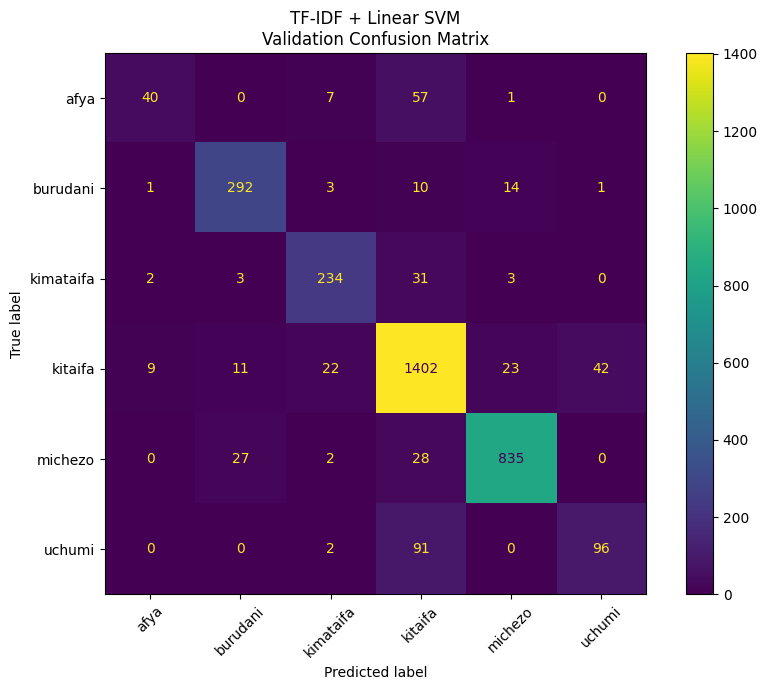

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = sorted(train_df["category"].unique())

svm_cm = confusion_matrix(
    val_df["category"],
    svm_val_predictions,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=svm_cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(9, 7))

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title(
    "TF-IDF + Linear SVM\nValidation Confusion Matrix"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Linear SVM Results

The TF-IDF Linear SVM achieved a validation accuracy of **0.8814**, macro-F1 of **0.7818**, and weighted-F1 of **0.8760**. It therefore outperformed the TF-IDF Logistic Regression baseline, which achieved a macro-F1 of 0.7532.

The improvement was particularly noticeable for the minority categories. The F1-score for `afya` increased from 0.4054 with Logistic Regression to **0.5096**, while `uchumi` increased from 0.5333 to **0.5854**. `Afya` recall also improved from 0.2857 to **0.3810**.

The confusion matrix shows that the previously identified tendency to classify minority articles as `kitaifa` remains, but is reduced. `Afya` articles incorrectly classified as `kitaifa` decreased from 72 under Logistic Regression to **57**, while `uchumi` articles classified as `kitaifa` decreased from 107 to **91**.

Nevertheless, the minority categories remain considerably more difficult than the larger categories. `Michezo`, for example, achieved an F1-score of 0.9446, compared with 0.5096 for `afya`.

These results establish Linear SVM as a strong classical baseline. The subsequent neural experiments will investigate whether explicitly modelling sequential or contextual information can improve macro-F1 and further reduce errors on the minority categories.

## 18. Bidirectional LSTM

The first neural sequential approach is a Bidirectional Long Short-Term Memory (BiLSTM) network.

Unlike TF-IDF-based approaches, the BiLSTM receives articles as ordered token sequences. LSTM networks use gated recurrent mechanisms designed to retain and update information across sequences, while bidirectional processing allows information from both earlier and later positions in the sequence to contribute to the learned representation.

This experiment investigates whether explicitly modelling sequential dependencies provides an advantage over the strong TF-IDF baselines.

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(
    train_df["category"]
)

y_val = label_encoder.transform(
    val_df["category"]
)

print("Label mapping:")

for i, label in enumerate(label_encoder.classes_):
    print(f"{i} -> {label}")

Label mapping:
0 -> afya
1 -> burudani
2 -> kimataifa
3 -> kitaifa
4 -> michezo
5 -> uchumi


In [ ]:
VOCAB_SIZE = 40000

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 40000

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>",
    lower=True
)

# IMPORTANT:
# Fit vocabulary using TRAINING DATA ONLY
tokenizer.fit_on_texts(
    train_df["clean_content"]
)

train_sequences = tokenizer.texts_to_sequences(
    train_df["clean_content"]
)

val_sequences = tokenizer.texts_to_sequences(
    val_df["clean_content"]
)

print("Training sequences:", len(train_sequences))
print("Validation sequences:", len(val_sequences))

print("\nExample sequence:")
print(train_sequences[0][:30])

Training sequences: 15348
Validation sequences: 3289

Example sequence:
[1232, 259, 1270, 20, 2, 259, 3393, 907, 25, 11, 930, 21923, 472, 1356, 25, 2, 1197, 4919, 338, 25, 8, 2011, 3843, 3, 1428, 10, 60, 1076, 298, 231]


In [ ]:
import numpy as np

train_sequence_lengths = np.array(
    [len(sequence) for sequence in train_sequences]
)

print("TOKENIZED TRAINING SEQUENCE LENGTHS")
print("=" * 45)

print(f"Median: {np.median(train_sequence_lengths):.0f}")

for percentile in [75, 90, 95, 99]:
    print(
        f"{percentile}th percentile: "
        f"{np.percentile(train_sequence_lengths, percentile):.0f}"
    )

print(
    f"Maximum: {train_sequence_lengths.max()}"
)

TOKENIZED TRAINING SEQUENCE LENGTHS
Median: 274
75th percentile: 398
90th percentile: 596
95th percentile: 799
99th percentile: 1278
Maximum: 3960


### Sequence Representation

The tokenizer was fitted exclusively on the training data to prevent information from the validation set influencing vocabulary construction. A maximum vocabulary size of 40,000 was used because exploratory analysis revealed a very large long-tail vocabulary, with 80.31% of unique words occurring five times or fewer. Words outside the retained vocabulary are represented using an out-of-vocabulary token.

After tokenization, the median training sequence contained 274 tokens. The 75th, 90th, 95th, and 99th percentiles were 398, 596, 799, and 1,278 tokens respectively, while the maximum sequence contained 3,960 tokens.

A maximum sequence length of **600 tokens** was selected for the initial BiLSTM experiment. This closely corresponds to the 90th percentile of the training distribution and therefore preserves complete sequences for approximately 90% of training articles while avoiding the computational cost of recurrently processing the extreme long tail.

Articles shorter than 600 tokens are padded, while longer articles are truncated. Sequence length remains an experimental parameter and may be adjusted if validation results indicate that additional context is beneficial.

In [ ]:
MAX_LENGTH = 600

X_train_seq = pad_sequences(
    train_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_val_seq = pad_sequences(
    val_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("Training shape:", X_train_seq.shape)
print("Validation shape:", X_val_seq.shape)

print("\nExample padded sequence:")
print(X_train_seq[0][:30])

print("\nLast 20 positions:")
print(X_train_seq[0][-20:])

Training shape: (15348, 600)
Validation shape: (3289, 600)

Example padded sequence:
[ 1232   259  1270    20     2   259  3393   907    25    11   930 21923
   472  1356    25     2  1197  4919   338    25     8  2011  3843     3
  1428    10    60  1076   298   231]

Last 20 positions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights_array)
}

print("CLASS WEIGHTS")
print("=" * 40)

for class_id, weight in class_weights.items():
    print(
        f"{label_encoder.inverse_transform([class_id])[0]:12s}: "
        f"{weight:.4f}"
    )

CLASS WEIGHTS
afya        : 5.1992
burudani    : 1.7053
kimataifa   : 2.0126
kitaifa     : 0.3632
michezo     : 0.6145
uchumi      : 2.9068


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

EMBEDDING_DIM = 128
LSTM_UNITS = 64
NUM_CLASSES = len(label_encoder.classes_)

bilstm_model = Sequential([

    # Convert integer tokens into learned dense vectors
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),

    # Process sequence in both directions
    Bidirectional(
        LSTM(LSTM_UNITS)
    ),

    # Regularization
    Dropout(0.4),

    # Classification layer
    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

bilstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

bilstm_model.build(
    input_shape=(None, MAX_LENGTH)
)

bilstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 600, 128)       │     5,120,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,219,590 (19.91 MB)

 Trainable params: 5,219,590 (19.91 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_bilstm = bilstm_model.fit(
    X_train_seq,
    y_train,

    validation_data=(
        X_val_seq,
        y_val
    ),

    epochs=10,
    batch_size=64,

    class_weight=class_weights,

    callbacks=[early_stopping],

    verbose=1
)

Epoch 1/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - accuracy: 0.5915 - loss: 0.9663 - val_accuracy: 0.7133 - val_loss: 0.7530
Epoch 2/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.8339 - loss: 0.3505 - val_accuracy: 0.8276 - val_loss: 0.5244
Epoch 3/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.9146 - loss: 0.1920 - val_accuracy: 0.8507 - val_loss: 0.5188
Epoch 4/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.9537 - loss: 0.0984 - val_accuracy: 0.8839 - val_loss: 0.4655
Epoch 5/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.9586 - loss: 0.0838 - val_accuracy: 0.8732 - val_loss: 0.5062
Epoch 6/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.9819 - loss: 0.0369 - val_accuracy: 0.8656 - val_loss: 0.6128


### BiLSTM Training Behaviour

The exact epoch values are reported by the training output above and may vary slightly across TensorFlow/CUDA versions even with fixed seeds. The interpretation should therefore be based on the **current run**. Early stopping monitors validation loss with `patience=2` and restores the weights from the epoch with the lowest validation loss. A widening gap in which training loss continues to fall while validation loss stops improving is treated as evidence of overfitting.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)
import numpy as np

# Predict probabilities
bilstm_probabilities = bilstm_model.predict(
    X_val_seq,
    verbose=0
)

# Convert probabilities to class IDs
bilstm_predictions_encoded = np.argmax(
    bilstm_probabilities,
    axis=1
)

# Convert IDs back to category names
bilstm_predictions = label_encoder.inverse_transform(
    bilstm_predictions_encoded
)

y_val_labels = label_encoder.inverse_transform(y_val)

# Calculate metrics
bilstm_accuracy = accuracy_score(
    y_val_labels,
    bilstm_predictions
)

bilstm_macro_f1 = f1_score(
    y_val_labels,
    bilstm_predictions,
    average="macro"
)

bilstm_weighted_f1 = f1_score(
    y_val_labels,
    bilstm_predictions,
    average="weighted"
)

print("BiLSTM VALIDATION RESULTS")
print("=" * 45)

print(f"Validation Accuracy:    {bilstm_accuracy:.4f}")
print(f"Validation Macro-F1:    {bilstm_macro_f1:.4f}")
print(f"Validation Weighted-F1: {bilstm_weighted_f1:.4f}")

print("\nCLASSIFICATION REPORT")
print("=" * 45)

print(
    classification_report(
        y_val_labels,
        bilstm_predictions,
        digits=4
    )
)

BiLSTM VALIDATION RESULTS
Validation Accuracy:    0.8839
Validation Macro-F1:    0.8030
Validation Weighted-F1: 0.8854

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        afya     0.4857    0.4857    0.4857       105
    burudani     0.8860    0.9439    0.9140       321
   kimataifa     0.8512    0.9011    0.8754       273
     kitaifa     0.9152    0.8728    0.8935      1509
     michezo     0.9600    0.9428    0.9514       892
      uchumi     0.6261    0.7884    0.6979       189

    accuracy                         0.8839      3289
   macro avg     0.7874    0.8224    0.8030      3289
weighted avg     0.8889    0.8839    0.8854      3289



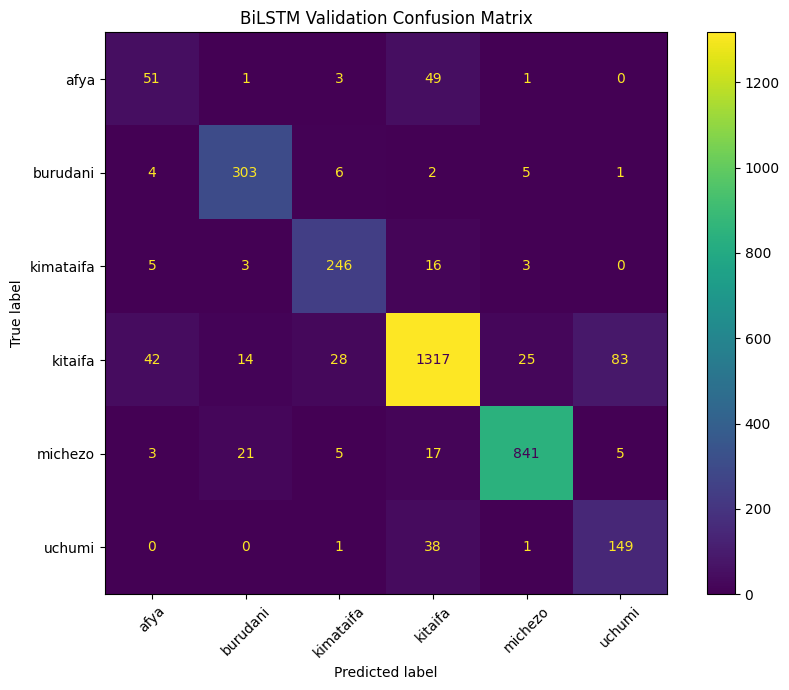

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = list(label_encoder.classes_)

bilstm_cm = confusion_matrix(
    y_val_labels,
    bilstm_predictions,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=bilstm_cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(9, 7))

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title(
    "BiLSTM Validation Confusion Matrix"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

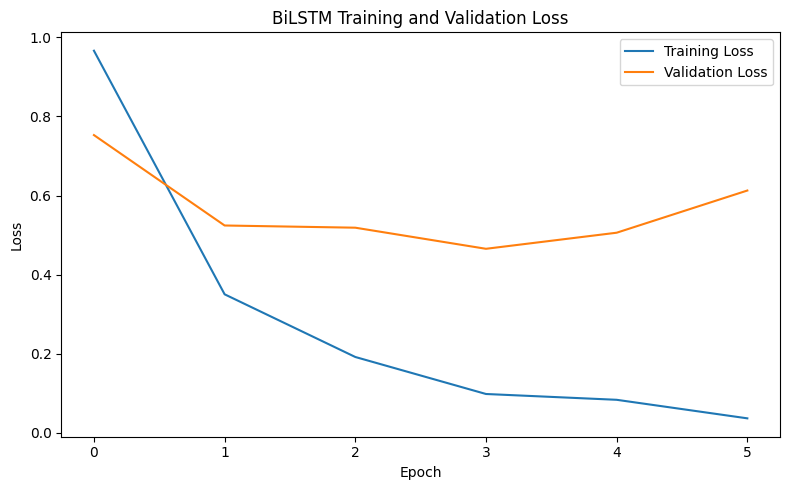

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_bilstm.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_bilstm.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BiLSTM Training and Validation Loss")
plt.legend()
plt.tight_layout()

plt.show()

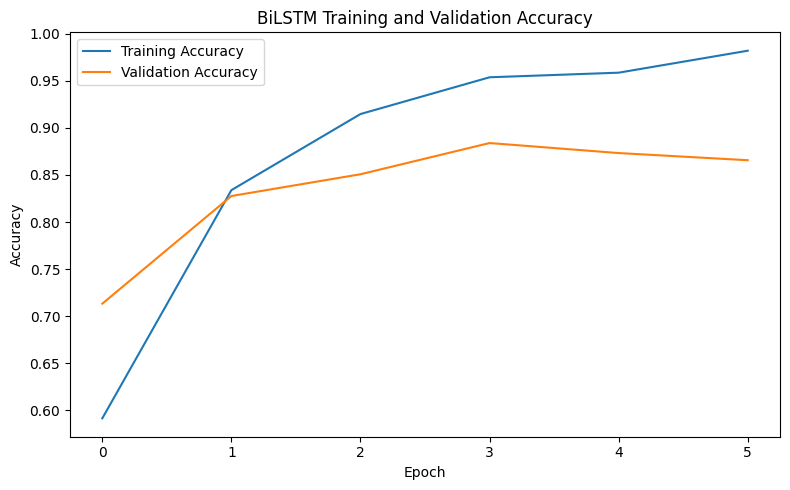

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_bilstm.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_bilstm.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BiLSTM Training and Validation Accuracy")
plt.legend()
plt.tight_layout()

plt.show()

### BiLSTM Results and Analysis

The BiLSTM achieved a **validation accuracy of 0.8839**, **macro-F1 of 0.8030**, and **weighted-F1 of 0.8854**. This was a meaningful improvement over Logistic Regression (macro-F1 **0.7532**) and Linear SVM (**0.7818**), showing that bidirectional recurrent sequence modelling added value beyond the sparse lexical baselines in this run.

Class-level results reveal an important trade-off. Performance was strongest for `michezo` (F1 **0.9514**), `burudani` (**0.9140**), `kitaifa` (**0.8935**) and `kimataifa` (**0.8754**). The minority classes remained harder: `afya` achieved F1 **0.4857**, while `uchumi` achieved **0.6979**. For `uchumi`, recall (**0.7884**) was substantially higher than precision (**0.6261**), which is consistent with the use of class weighting: the model became more sensitive to the minority class but also produced additional false positives.

The learning history also shows why early stopping was useful. Validation loss improved to its lowest value at epoch 4 (**0.4655**) and then increased to **0.5062** and **0.6128** in epochs 5 and 6 while training performance continued to improve. Restoring the best weights therefore limited the effect of later overfitting.


## 19. One-Dimensional Convolutional Neural Network

The second neural architecture is a one-dimensional Convolutional Neural Network (1D CNN). While the BiLSTM recurrently processes the article sequence, the CNN learns filters that detect informative local patterns across neighbouring token embeddings.

This provides an architecturally different form of sequential modelling. News categories may contain characteristic local expressions, terminology, and short phrases that can provide strong classification signals.

To make the comparison with the BiLSTM more controlled, the CNN uses the same 40,000-token vocabulary, 600-token input sequences, training-validation split, learned embedding dimensionality, and class-weighting strategy.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)

tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

cnn_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128
    ),

    Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu"
    ),

    GlobalMaxPooling1D(),

    Dropout(0.4),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.build(
    input_shape=(None, MAX_LENGTH)
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 600, 128)       │     5,120,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 596, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,210,694 (19.88 MB)

 Trainable params: 5,210,694 (19.88 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_cnn = cnn_model.fit(
    X_train_seq,
    y_train,

    validation_data=(
        X_val_seq,
        y_val
    ),

    epochs=10,
    batch_size=64,

    class_weight=class_weights,

    callbacks=[cnn_early_stopping],

    verbose=1
)

Epoch 1/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.5059 - loss: 1.2431 - val_accuracy: 0.6762 - val_loss: 0.8097
Epoch 2/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7257 - loss: 0.6223 - val_accuracy: 0.7616 - val_loss: 0.6216
Epoch 3/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8087 - loss: 0.4053 - val_accuracy: 0.8072 - val_loss: 0.5381
Epoch 4/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8733 - loss: 0.2649 - val_accuracy: 0.8398 - val_loss: 0.4878
Epoch 5/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9247 - loss: 0.1629 - val_accuracy: 0.8556 - val_loss: 0.4847
Epoch 6/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9504 - loss: 0.1103 - val_accuracy: 0.8583 - val_loss: 0.4877
Epoch 7/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9692 - loss: 0.0703 - val_accuracy: 0.8592 - val_loss: 0.5331


### CNN Training Behaviour

The exact epoch values are reported by the training output above and can vary slightly across TensorFlow/CUDA versions. Early stopping monitors validation loss with `patience=2` and restores the weights from the epoch with the lowest validation loss. The learning curves below should be used to identify the point at which validation loss stops improving while training loss continues to decrease.

This makes the interpretation reproducible even if a rerun produces slightly different epoch-level values.


In [ ]:
# Predict validation probabilities
cnn_probabilities = cnn_model.predict(
    X_val_seq,
    verbose=0
)

# Convert probabilities to class IDs
cnn_predictions_encoded = np.argmax(
    cnn_probabilities,
    axis=1
)

# Convert back to category names
cnn_predictions = label_encoder.inverse_transform(
    cnn_predictions_encoded
)

# Metrics
cnn_accuracy = accuracy_score(
    y_val_labels,
    cnn_predictions
)

cnn_macro_f1 = f1_score(
    y_val_labels,
    cnn_predictions,
    average="macro"
)

cnn_weighted_f1 = f1_score(
    y_val_labels,
    cnn_predictions,
    average="weighted"
)

print("1D CNN VALIDATION RESULTS")
print("=" * 45)

print(f"Validation Accuracy:    {cnn_accuracy:.4f}")
print(f"Validation Macro-F1:    {cnn_macro_f1:.4f}")
print(f"Validation Weighted-F1: {cnn_weighted_f1:.4f}")

print("\nCLASSIFICATION REPORT")
print("=" * 45)

print(
    classification_report(
        y_val_labels,
        cnn_predictions,
        digits=4
    )
)

1D CNN VALIDATION RESULTS
Validation Accuracy:    0.8556
Validation Macro-F1:    0.7894
Validation Weighted-F1: 0.8614

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        afya     0.5417    0.6190    0.5778       105
    burudani     0.8409    0.9221    0.8796       321
   kimataifa     0.8333    0.9158    0.8726       273
     kitaifa     0.9213    0.8072    0.8605      1509
     michezo     0.9497    0.9316    0.9406       892
      uchumi     0.4813    0.8148    0.6051       189

    accuracy                         0.8556      3289
   macro avg     0.7614    0.8351    0.7894      3289
weighted avg     0.8765    0.8556    0.8614      3289



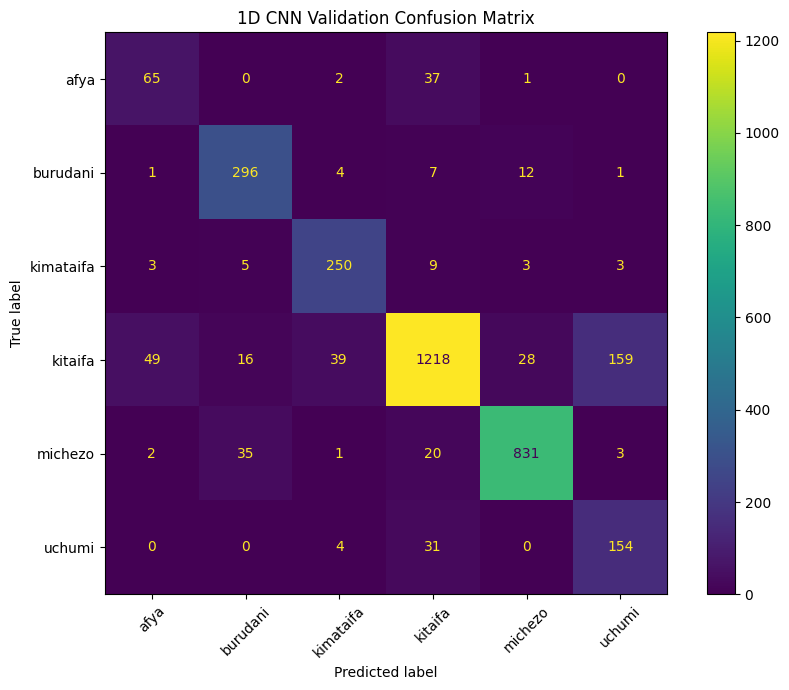

In [ ]:
cnn_cm = confusion_matrix(
    y_val_labels,
    cnn_predictions,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cnn_cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(9, 7))

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title("1D CNN Validation Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

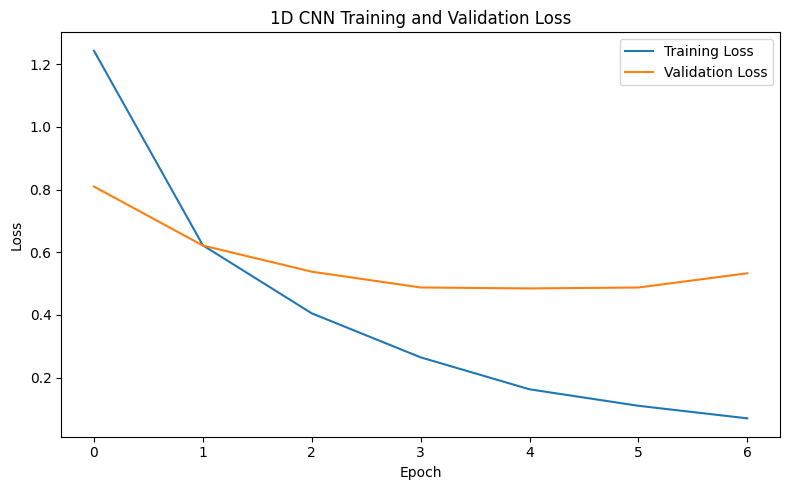

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_cnn.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_cnn.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("1D CNN Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

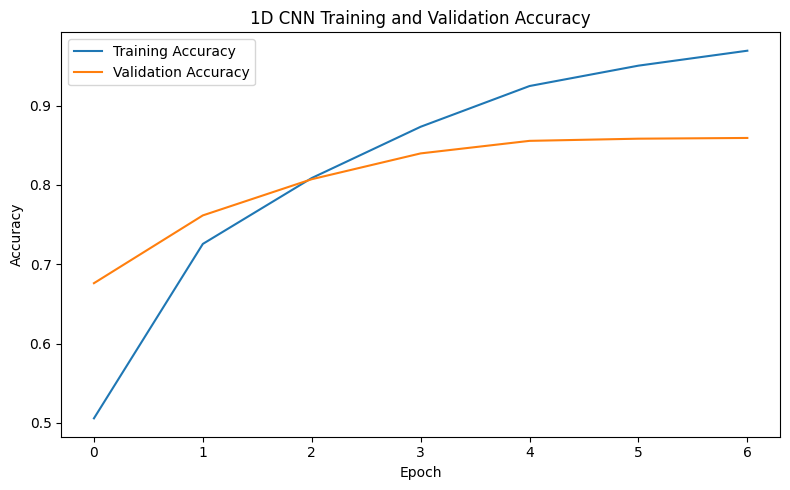

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_cnn.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_cnn.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("1D CNN Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

### 1D CNN Results and Analysis

The 1D CNN achieved a **validation accuracy of 0.8556**, **macro-F1 of 0.7894**, and **weighted-F1 of 0.8614**. Its macro-F1 was slightly higher than Linear SVM (**0.7818**) but lower than the BiLSTM (**0.8030**). This suggests that local convolutional sequence patterns were useful, but they did not provide as large an improvement as the bidirectional recurrent model in this run.

The CNN performed strongly on `michezo` (F1 **0.9406**), `burudani` (**0.8796**), `kimataifa` (**0.8726**) and `kitaifa` (**0.8605**). Minority-class behaviour again shows the effect of class weighting. `Afya` achieved recall **0.6190** and F1 **0.5778**, while `uchumi` achieved recall **0.8148** but precision only **0.4813**, producing an F1 of **0.6051**. The high `uchumi` recall therefore came with a substantial precision cost.

Validation loss reached its minimum at epoch 5 (**0.4847**). Although validation accuracy continued to rise slightly afterward, validation loss increased to **0.4877** and then **0.5331**, while training accuracy reached **0.9692** by epoch 7. Restoring the best validation-loss weights was therefore appropriate and reduced the impact of overfitting.


In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [ ]:
!pip install -q transformers datasets accelerate sentencepiece

In [ ]:
import torch
import numpy as np

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

## 20. Transformer-Based Classification with XLM-RoBERTa

The final approach uses **XLM-RoBERTa (XLM-R)**, a pretrained multilingual Transformer. Unlike the BiLSTM and CNN, whose embeddings are learned from the task-specific Swahili news training set, XLM-R begins with contextual representations learned through large-scale multilingual pretraining.

XLM-R was pretrained on text from **100 languages**, and Conneau et al. (2020) reported strong cross-lingual results including gains for Swahili. Its subword tokenization is relevant to the present dataset because exploratory analysis identified **201,361 unique word forms**, with **80.31% occurring five times or fewer**.

The Transformer provides a substantially different sequential approach from TF-IDF, convolutional modelling, and recurrent modelling. Self-attention allows token representations to depend on other positions in the input without recurrently processing the sequence one token at a time (Vaswani et al., 2017).

### Computational configuration

The successful fine-tuning experiment used a maximum input length of **128 subword tokens**. The training batch size was reduced to **2** and evaluation batch size to **4** to fit the available Tesla T4 GPU memory. **Gradient accumulation over four steps** maintained an effective training batch size of 8. The model was trained for three epochs with a learning rate of `2e-5`, weight decay of `0.01`, mixed precision when CUDA was available, and model selection based on validation macro-F1.

The 128-token limit is an explicit computational trade-off: longer articles are truncated, so information appearing later in an article may be lost. This limitation is considered when interpreting the results.


In [ ]:
MODEL_NAME = "FacebookAI/xlm-roberta-base"

xlmr_tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

In [ ]:
# ============================================================
# XLM-R DATA PREPARATION — COMPLETE SELF-CONTAINED CELL
# ============================================================

import numpy as np
import torch

from datasets import Dataset
from transformers import AutoTokenizer

# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

MODEL_NAME = "FacebookAI/xlm-roberta-base"
TRANSFORMER_MAX_LENGTH = 128


# ------------------------------------------------------------
# 2. Prepare training and validation DataFrames
# ------------------------------------------------------------

train_transformer_df = train_df[
    ["clean_content", "category"]
].copy()

val_transformer_df = val_df[
    ["clean_content", "category"]
].copy()


# ------------------------------------------------------------
# 3. Convert category names to integer labels
# ------------------------------------------------------------

train_transformer_df["label"] = label_encoder.transform(
    train_transformer_df["category"]
)

val_transformer_df["label"] = label_encoder.transform(
    val_transformer_df["category"]
)


print("Label mapping:")

for i, label in enumerate(label_encoder.classes_):
    print(f"{i} -> {label}")


# ------------------------------------------------------------
# 4. Create Hugging Face datasets
# ------------------------------------------------------------

train_dataset = Dataset.from_pandas(
    train_transformer_df[
        ["clean_content", "label"]
    ],
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_transformer_df[
        ["clean_content", "label"]
    ],
    preserve_index=False
)


print("\nDATASETS BEFORE TOKENIZATION")
print("=" * 50)

print("Training examples:", len(train_dataset))
print("Validation examples:", len(val_dataset))


# ------------------------------------------------------------
# 5. Load XLM-R tokenizer
# ------------------------------------------------------------

xlmr_tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)


# ------------------------------------------------------------
# 6. Tokenization function
# ------------------------------------------------------------

def tokenize_function(batch):

    return xlmr_tokenizer(
        batch["clean_content"],
        truncation=True,
        max_length=TRANSFORMER_MAX_LENGTH,
        padding="max_length"
    )


# ------------------------------------------------------------
# 7. Tokenize datasets
# ------------------------------------------------------------

tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_val = val_dataset.map(
    tokenize_function,
    batched=True
)


# ------------------------------------------------------------
# 8. Remove original text after tokenization
# ------------------------------------------------------------

tokenized_train = tokenized_train.remove_columns(
    ["clean_content"]
)

tokenized_val = tokenized_val.remove_columns(
    ["clean_content"]
)


# ------------------------------------------------------------
# 9. Convert to PyTorch format
# ------------------------------------------------------------

tokenized_train.set_format("torch")
tokenized_val.set_format("torch")


# ------------------------------------------------------------
# 10. Verify everything
# ------------------------------------------------------------

print("\nTOKENIZATION COMPLETE")
print("=" * 50)

print("Training examples:", len(tokenized_train))
print("Validation examples:", len(tokenized_val))

print("\nColumns:")
print(tokenized_train.column_names)

print("\nExample input length:")
print(len(tokenized_train[0]["input_ids"]))

print("\nExample label:")
print(tokenized_train[0]["label"])

Label mapping:
0 -> afya
1 -> burudani
2 -> kimataifa
3 -> kitaifa
4 -> michezo
5 -> uchumi

DATASETS BEFORE TOKENIZATION
Training examples: 15348
Validation examples: 3289


Map:   0%|          | 0/15348 [00:00<?, ? examples/s]

Map:   0%|          | 0/3289 [00:00<?, ? examples/s]


TOKENIZATION COMPLETE
Training examples: 15348
Validation examples: 3289

Columns:
['label', 'input_ids', 'attention_mask']

Example input length:
128

Example label:
tensor(2)


In [ ]:
from transformers import AutoModelForSequenceClassification

NUM_CLASSES = len(label_encoder.classes_)

id2label = {
    i: label
    for i, label in enumerate(label_encoder.classes_)
}

label2id = {
    label: i
    for i, label in enumerate(label_encoder.classes_)
}

xlmr_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    id2label=id2label,
    label2id=label2id
)

print("XLM-R model loaded successfully.")
print("Number of classes:", NUM_CLASSES)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


XLM-R model loaded successfully.
Number of classes: 6


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score
)

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    return {
        "accuracy": accuracy_score(
            labels,
            predictions
        ),

        "macro_f1": f1_score(
            labels,
            predictions,
            average="macro"
        ),

        "weighted_f1": f1_score(
            labels,
            predictions,
            average="weighted"
        )
    }

In [ ]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

CUDA available: True
GPU: Tesla T4


In [ ]:
from transformers import TrainingArguments, set_seed
import torch

set_seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

training_args = TrainingArguments(
    output_dir="./xlmr_swahili_news",

    learning_rate=2e-5,

    # Reduced to prevent Colab/T4 crashing
    per_device_train_batch_size=2,
    per_device_eval_batch_size=4,

    # Maintains an effective batch size of 8
    gradient_accumulation_steps=4,

    num_train_epochs=3,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="macro_f1",
    greater_is_better=True,

    fp16=torch.cuda.is_available(),

    logging_steps=100,

    save_total_limit=1,

    report_to="none",

    seed=42
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=xlmr_model,

    args=training_args,

    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,

    processing_class=xlmr_tokenizer,

    compute_metrics=compute_metrics
)

print("Trainer created successfully.")

Trainer created successfully.


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.705948,0.454247,0.911827,0.821841,0.906705
2,1.449184,0.398362,0.925509,0.871317,0.925779
3,0.845436,0.419592,0.925205,0.865384,0.924310


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5757, training_loss=1.5735460831014485, metrics={'train_runtime': 1699.2332, 'train_samples_per_second': 27.097, 'train_steps_per_second': 3.388, 'total_flos': 3028780131121152.0, 'train_loss': 1.5735460831014485, 'epoch': 3.0})

### XLM-R Training Results

XLM-R produced the strongest validation performance of the five learned approaches. Using the best checkpoint selected by validation macro-F1, it achieved **0.9255 validation accuracy**, **0.8713 macro-F1**, and **0.9258 weighted-F1**.

Its class-level results were also comparatively balanced. F1 scores were **0.9646** for `michezo`, **0.9385** for `burudani`, **0.9336** for `kimataifa`, **0.9313** for `kitaifa`, **0.8293** for `uchumi`, and **0.6306** for `afya`. `Afya` remained the most difficult category, but XLM-R improved substantially on the minority-class performance seen in the earlier approaches.

Compared with the next-best validation macro-F1, BiLSTM at **0.8030**, XLM-R improved macro-F1 by **0.0683**. This result supports the usefulness of multilingual contextual pretraining and subword representation for the task. However, the gain cannot be attributed solely to Transformer architecture because XLM-R also benefits from large-scale multilingual pretraining. The **128-token** input limit remains a computational limitation because later portions of long articles are truncated.


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import numpy as np
import matplotlib.pyplot as plt

# Predictions from the restored best model
xlmr_output = trainer.predict(tokenized_val)

xlmr_predictions_encoded = np.argmax(
    xlmr_output.predictions,
    axis=-1
)

xlmr_predictions = label_encoder.inverse_transform(
    xlmr_predictions_encoded
)

xlmr_true_labels = label_encoder.inverse_transform(
    xlmr_output.label_ids
)

print("XLM-R CLASSIFICATION REPORT")
print("=" * 50)

print(
    classification_report(
        xlmr_true_labels,
        xlmr_predictions,
        digits=4
    )
)

XLM-R CLASSIFICATION REPORT
              precision    recall  f1-score   support

        afya     0.5983    0.6667    0.6306       105
    burudani     0.9271    0.9502    0.9385       321
   kimataifa     0.9405    0.9267    0.9336       273
     kitaifa     0.9417    0.9211    0.9313      1509
     michezo     0.9510    0.9787    0.9646       892
      uchumi     0.8500    0.8095    0.8293       189

    accuracy                         0.9255      3289
   macro avg     0.8681    0.8755    0.8713      3289
weighted avg     0.9265    0.9255    0.9258      3289



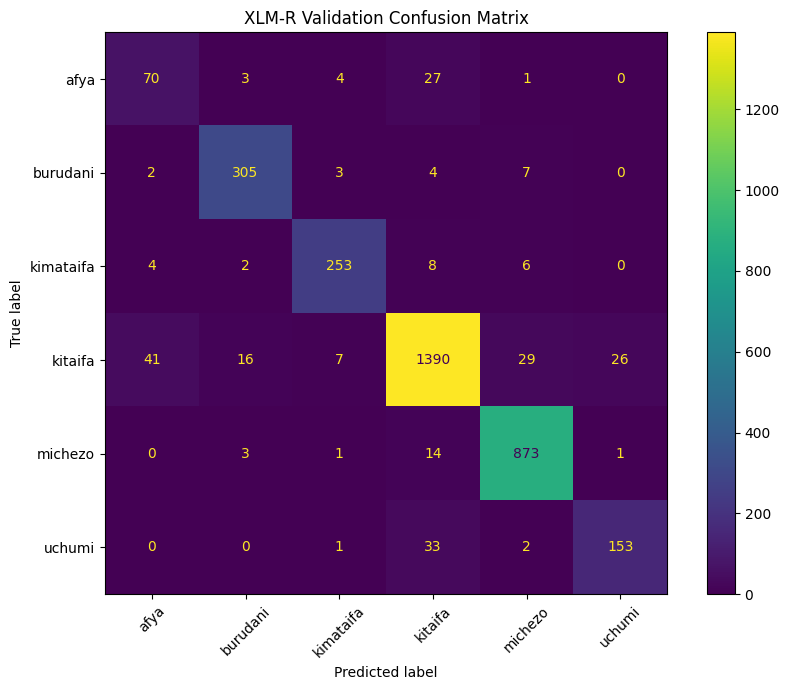

In [ ]:
labels = list(label_encoder.classes_)

xlmr_cm = confusion_matrix(
    xlmr_true_labels,
    xlmr_predictions,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=xlmr_cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(9, 7))

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title("XLM-R Validation Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Comparison of the Five Modelling Approaches

The validation results show a clear progression across the five approaches:

| Model | Validation Accuracy | Validation Macro-F1 | Validation Weighted-F1 |
|---|---:|---:|---:|
| TF-IDF + Logistic Regression | 0.8729 | 0.7532 | 0.8643 |
| TF-IDF + Linear SVM | 0.8814 | 0.7818 | 0.8760 |
| BiLSTM | 0.8839 | 0.8030 | 0.8854 |
| 1D CNN | 0.8556 | 0.7894 | 0.8614 |
| **XLM-R** | **0.9255** | **0.8713** | **0.9258** |

Linear SVM improved macro-F1 from **0.7532** to **0.7818** relative to Logistic Regression, confirming that a strong margin-based lexical baseline is highly competitive for document classification. The task-specific neural models produced mixed gains: the 1D CNN reached **0.7894**, while the BiLSTM reached **0.8030**, the strongest result before multilingual pretraining.

XLM-R was clearly strongest, reaching **0.8713 macro-F1**, an absolute improvement of **0.0683** over BiLSTM. Its advantage was also visible in minority-class performance, especially `uchumi` (F1 **0.8293**), although `afya` remained the weakest class at **0.6306**.

These results show that neural architecture alone did not guarantee a large improvement over TF-IDF. The major gain appeared when contextual Transformer modelling was combined with multilingual pretraining and subword tokenization. For that reason, XLM-R's advantage should be interpreted as a combined effect of architecture, representation and pretraining rather than self-attention alone.


In [ ]:
error_df = val_df[
    ["id", "clean_content", "category"]
].copy().reset_index(drop=True)

error_df["predicted"] = xlmr_predictions

errors = error_df[
    error_df["category"] != error_df["predicted"]
].copy()

print("Total validation articles:", len(error_df))
print("Correct predictions:", len(error_df) - len(errors))
print("Incorrect predictions:", len(errors))
print(
    "Error rate:",
    f"{len(errors) / len(error_df) * 100:.2f}%"
)

Total validation articles: 3289
Correct predictions: 3044
Incorrect predictions: 245
Error rate: 7.45%


In [ ]:
error_pairs = (
    errors
    .groupby(["category", "predicted"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(error_pairs.head(15))

,category,predicted,count
12,kitaifa,afya,41
22,uchumi,kitaifa,33
15,kitaifa,michezo,29
2,afya,kitaifa,27
16,kitaifa,uchumi,26
13,kitaifa,burudani,16
19,michezo,kitaifa,14
10,kimataifa,kitaifa,8
7,burudani,michezo,7
14,kitaifa,kimataifa,7


In [ ]:
afya_kitaifa_errors = errors[
    (errors["category"] == "afya") &
    (errors["predicted"] == "kitaifa")
]

print(
    "Afya → Kitaifa errors:",
    len(afya_kitaifa_errors)
)

display(
    afya_kitaifa_errors[
        ["id", "category", "predicted", "clean_content"]
    ].head(10)
)

Afya → Kitaifa errors: 27


,id,category,predicted,clean_content
38,SW7070,afya,kitaifa,"Aveline Kitomary, Dar es Salaam Maabara ya Mke..."
160,SW23927,afya,kitaifa,"BEATRICE MOSSES, MANYARA Mwalimu Mkuu wa shule..."
180,SW2333,afya,kitaifa,Mwandishi Wetu-Tokyo TAASISI ya Association of...
187,SW22812,afya,kitaifa,MWANDISHI WETU -SONGWE MWENYEKITI wa Umoja wa ...
317,SW25519,afya,kitaifa,Na ANDREW MSECHU-DAR ES SALAAM KUTOTEKELEZWA k...
353,SW2925,afya,kitaifa,GRACE SHITUNDU Na DERICK MILTON – SIMIYU WAZIR...
381,SW27325,afya,kitaifa,FRANCIS GODWIN -IRINGA KUTOKANA na Jeshi la Po...
407,SW16328,afya,kitaifa,UTATA umeibuka kuhusiana na kifo cha mtoto Nor...
631,SW26504,afya,kitaifa,Na SAMWEL MWANGA WAZAZI na walezi wa watoto al...
686,SW2281,afya,kitaifa,"BODI ya Wadhamini ya Taasisi ya Mifupa, Upasua..."


In [ ]:
pd.set_option("display.max_colwidth", None)

for i, row in afya_kitaifa_errors.head(5).iterrows():

    print("\n" + "=" * 100)
    print("ID:", row["id"])
    print("TRUE LABEL:", row["category"])
    print("PREDICTED:", row["predicted"])
    print("-" * 100)

    print(row["clean_content"][:1500])


ID: SW7070
TRUE LABEL: afya
PREDICTED: kitaifa
----------------------------------------------------------------------------------------------------
Aveline Kitomary, Dar es Salaam Maabara ya Mkemia Mkuu wa Serikali inatarajia kuanzisha mfumo wa kanzidata wa taifa utakaosaidia kurahisisha utambuzi wa miili iliyoharibika na watu wanaojihusisha na uhalifu kwa haraka zaidi. Akizungumza na waandishi wa habari jana Dar es salaam wakati ya kuelezea mafanikio ya taasisi hiyo kwa miaka minne ya Rais Dk. John Magufuli amesema kazi data hiyo pia itasaidia katika matibabu. “Tunatarajia kumaliza database hiyo ndani ya miaka miwili na tutahakikisha watu wote nchi nzima wataingia kwenye mfumo huo tutashirikiana na taasisi zingine. “Database hii itasaidia kutambua miili iliyoharibika bila usumbufu wa kupima ndugu na pia kwa upande wa uhalifu kama mauaji, ubakaji ni rahisi kumtambua mhalifu bila kuchukua muda mrefu,” amesema Dk. Mafumiko.

ID: SW23927
TRUE LABEL: afya
PREDICTED: kitaifa
--------------

In [ ]:
kitaifa_afya_errors = errors[
    (errors["category"] == "kitaifa") &
    (errors["predicted"] == "afya")
]

print(
    "Kitaifa → Afya errors:",
    len(kitaifa_afya_errors)
)

for i, row in kitaifa_afya_errors.head(5).iterrows():

    print("\n" + "=" * 100)
    print("ID:", row["id"])
    print("TRUE LABEL:", row["category"])
    print("PREDICTED:", row["predicted"])
    print("-" * 100)

    print(row["clean_content"][:1500])

Kitaifa → Afya errors: 41

ID: SW13897
TRUE LABEL: kitaifa
PREDICTED: afya
----------------------------------------------------------------------------------------------------
RAYMOND MINJA IRINGA Kampuni ya Usindikaji maziwa ya Asas mkoani Iringa Asas imetoa msaada wa barakoa 500 kwa mama lishe wanaofanya biashara zao katika masoko matano yaliyoko manispaa ya Iringa kwa ajili ya kujinga na virusi vya corona. Akikabidhi msaada huo Afisa Usalama, Afya Mazingira na Ubora wa Kampuni hiyo, Cosmas Charles kwa niaba ya mkurugenzi wa uzalishaji wa kampuni hiyo, Ahmed Salim Abri amesema huo ni mwendelezo wa kampuni hiyo katika kusaidia jamii ambayo inahusisha mikusanyiko ya watu wengi zaidi ndani na nje ya mkoa wa Iringa Alisema kuwa msaada huo umewafikia mama lishe wanaofanya biashara katika masoko ya Mashine Tatu, Kihesa, Soko la kisasa la Mlandege, Soko Kuu la Iringa na soko la Ipogoro ambapo kuna mwingiliano wa watu wengi wanaopata mahitaji sokoni hapo. Amesema kampuni ya Asas imekuwa na u

In [ ]:
uchumi_kitaifa_errors = errors[
    (errors["category"] == "uchumi") &
    (errors["predicted"] == "kitaifa")
]

kitaifa_uchumi_errors = errors[
    (errors["category"] == "kitaifa") &
    (errors["predicted"] == "uchumi")
]

print("Uchumi → Kitaifa:", len(uchumi_kitaifa_errors))
print("Kitaifa → Uchumi:", len(kitaifa_uchumi_errors))


print("\n\nUCHUMI → KITAIFA EXAMPLES")

for i, row in uchumi_kitaifa_errors.head(5).iterrows():

    print("\n" + "=" * 100)
    print("ID:", row["id"])
    print("TRUE:", row["category"])
    print("PREDICTED:", row["predicted"])
    print("-" * 100)

    print(row["clean_content"][:1500])


print("\n\nKITAIFA → UCHUMI EXAMPLES")

for i, row in kitaifa_uchumi_errors.head(5).iterrows():

    print("\n" + "=" * 100)
    print("ID:", row["id"])
    print("TRUE:", row["category"])
    print("PREDICTED:", row["predicted"])
    print("-" * 100)

    print(row["clean_content"][:1500])

Uchumi → Kitaifa: 33
Kitaifa → Uchumi: 26


UCHUMI → KITAIFA EXAMPLES

ID: SW879
TRUE: uchumi
PREDICTED: kitaifa
----------------------------------------------------------------------------------------------------
WAZIRI Mkuu, Kassim Majaliwa ametaka Watanzania wanaoweza kuunganisha nguvu na wawekezaji kutoka nchi wanachama wa Jumuiya ya Maendeleo Kusini mwa Afrika (SADC), kufanya hivyo kwa kuwekeza kwenye viwanda vikubwa.Aidha, Majaliwa aliyeeleza kuvutiwa na Maonesho ya Wiki ya SADC, amesisitiza Watanzania kutumia maonesho ya viwanda ya SADC kukaribisha wageni kwa ukarimu, kutangaza mambo mazuri ya nchi ikiwamo vivutio vya utalii.Alitoa mwito huo jana jijini Dar es Salaam baada ya kutembelea mabanda ya maonesho na kujionea bidhaambali mbali, zinazooneshwa na washiriki kutoka nchi wanachama wa jumuiya. Waziri Mkuu alisema kupitia maonesho hayo, nchi wanachama wa jumuiya wanayo fursa ya kuanzisha viwanda nchini. SADC inaundwa na nchi 16.“Watanzania mnaoweza kuunganisha nguvu na nchi wa

## Error Analysis

XLM-R correctly classified **3,044 of 3,289** validation articles and misclassified **245**, giving an error rate of **7.45%**. The errors were not evenly distributed. The most frequent confusion was `kitaifa → afya` (**41** cases), followed by `uchumi → kitaifa` (**33**), `kitaifa → michezo` (**29**), `afya → kitaifa` (**27**), and `kitaifa → uchumi` (**26**).

A recurring difficulty is therefore the boundary between the broad `kitaifa` category and more specialised categories. The `afya`–`kitaifa` boundary alone produced **68 directional errors** (41 + 27). Manual inspection showed that health stories are often framed through government programmes, institutions, budgets or public administration, making both labels semantically plausible. Similarly, economic stories can centre on ministers and national policy, explaining the two-way `uchumi`–`kitaifa` confusion.

This pattern is supported independently by the EDA. The dataset contained **271 unique article texts with conflicting labels**, involving **630 rows**, and `afya`–`kitaifa` was the most frequent conflicting-label pair. Consequently, some measured errors are plausibly related to overlapping category boundaries or annotation noise rather than only model failure.

The error analysis therefore complements the aggregate score of **0.8713 validation macro-F1**: XLM-R performs strongly overall, but its remaining errors reveal systematic ambiguity in the underlying classification task.


In [ ]:
kitaifa_michezo = errors[
    (errors["category"] == "kitaifa") &
    (errors["predicted"] == "michezo")
]

michezo_kitaifa = errors[
    (errors["category"] == "michezo") &
    (errors["predicted"] == "kitaifa")
]

print("Kitaifa → Michezo:", len(kitaifa_michezo))
print("Michezo → Kitaifa:", len(michezo_kitaifa))

print("\nKITAIFA → MICHEZO EXAMPLES")

for _, row in kitaifa_michezo.head(5).iterrows():
    print("\n" + "=" * 100)
    print("ID:", row["id"])
    print("TRUE:", row["category"])
    print("PREDICTED:", row["predicted"])
    print("-" * 100)
    print(row["clean_content"][:1500])

print("\nMICHEZO → KITAIFA EXAMPLES")

for _, row in michezo_kitaifa.head(5).iterrows():
    print("\n" + "=" * 100)
    print("ID:", row["id"])
    print("TRUE:", row["category"])
    print("PREDICTED:", row["predicted"])
    print("-" * 100)
    print(row["clean_content"][:1500])

Kitaifa → Michezo: 29
Michezo → Kitaifa: 14

KITAIFA → MICHEZO EXAMPLES

ID: SW19124
TRUE: kitaifa
PREDICTED: michezo
----------------------------------------------------------------------------------------------------
SIMBA na Yanga zinatarajia kushuka uwanjani kesho na keshokutwa kwa ajili ya michezo ya kujipima nguvu wakati ligi ikiwa imesimama kupisha mechi za kimataifa ikiwemo ya Tanzania na Uganda itakayochezwa kesho mjini Kampala. Timu hizo zote zinatarajia kutumia Uwanja wa Taifa Dar es Salaam kwa ajili ya mechi zao hizo.Simba itaanza kesho kuumana na AFC Leopards ya Kenya wakati Yanga itacheza keshokutwa na African Lyon inayoshiriki Ligi Kuu Bara. Simba iliyo chini ya Patrick Aussems imeamua kutafuta mechi ya kimataifa kwa ajili ya kujiweka sawa na kurekebisha makosa aliyoyashuhudia katika mechi zake mbili za awali za Ligi Kuu wakati wakijiandaa kukutana na Ndanda FC baada ya kurejea kwa ligi wiki ijayo. Ofisa Habari wa Simba, Haji Manara alikaririwa hivi karibuni akiwaita mas

### Michezo and Kitaifa

The `kitaifa`–`michezo` boundary accounted for another 43 errors: 29 `kitaifa → michezo` predictions and 14 `michezo → kitaifa` predictions. Manual examination suggests that some of these cases may reflect category ambiguity or noisy annotation rather than straightforward model failure.

Several articles labelled `kitaifa` contain strongly sports-oriented content. For example, SW19124 discusses Simba and Yanga, football fixtures, league preparation, coaches and players. SW21171 focuses on Liverpool forward Sadio Mané, Jürgen Klopp and events during football matches. In such cases, XLM-R's prediction of `michezo` is semantically plausible based on the visible article content.

The reverse direction provides further evidence of difficult category boundaries. Some articles labelled `michezo` contain little explicit sporting content. SW25667 concerns tourism and preservation of the Zinjathropus site; SW12550 discusses Maasai traditions and cultural education; SW21664 concerns cultural relations between China and Tanzania; and SW25858 discusses marriage and family life from a religious perspective. XLM-R predicted these articles as `kitaifa`.

These examples should not automatically be treated as proof of incorrect ground-truth labels because the original annotation guidelines are not available in this investigation. However, they provide evidence that some measured classification errors may result from broad category definitions, multi-topic articles, or potentially noisy labels.

Together with the previously identified `afya`–`kitaifa` and `uchumi`–`kitaifa` confusion, these examples show that the remaining errors are concentrated partly around semantic category boundaries rather than being uniformly distributed or random.

## Limitations and Future Work

Several limitations should be considered when interpreting the results of this investigation.

First, the dataset is substantially imbalanced. After cleaning and deduplication, `kitaifa` represented 45.88% of the data, while `afya` represented only 3.20%. Although macro-F1 and class weighting were used to reduce the influence of this imbalance during evaluation and neural-model training, minority classes still had considerably fewer examples from which to learn.

Second, exploratory analysis revealed potential label ambiguity and duplication. A total of 271 unique article texts appeared with conflicting category labels, involving 630 rows. This problem was particularly pronounced for `afya`, where 18.04% of the original class rows were involved in conflicting-label texts. Conflicting texts were excluded from the modelling dataset to prevent identical content with different labels from appearing across data splits. Nevertheless, manual error analysis suggests that broader category ambiguity may remain elsewhere in the dataset.

Third, many news articles contain multiple topics. A report may simultaneously concern healthcare and government policy, economics and national administration, or sport and broader social issues. Because the task uses single-label classification, the model must select one category even when multiple categories may reasonably describe an article.

Fourth, computational constraints affected the Transformer experiment. XLM-R was fine-tuned using a maximum sequence length of 128 subword tokens because longer sequences and larger batches exceeded the practical memory available in the experimental environment. Longer articles were therefore truncated, potentially removing useful information appearing later in the text.

Fifth, the BiLSTM and CNN were trained using task-specific embeddings, whereas XLM-R benefited from large-scale multilingual pretraining. The comparison therefore evaluates practical modelling approaches rather than isolating architecture as the only experimental variable. XLM-R's improvement should not be attributed solely to the Transformer architecture.

Sixth, hyperparameter exploration was limited by available computational resources. More extensive tuning could change the relative performance of the models, particularly the neural architectures.

Future work could investigate improved annotation guidelines and manual review of ambiguous labels, additional minority-class examples, data augmentation, pretrained African-language or Swahili-specific language models, and longer-context modelling. A multi-label formulation could also be investigated because some news articles clearly contain information relevant to more than one topic. Further experiments could examine different Transformer sequence lengths and more extensive hyperparameter optimisation.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer

print("FOUND MODELS")
print("=" * 50)

for name, obj in list(globals().items()):

    if isinstance(obj, LogisticRegression):
        print("Logistic Regression:", name)

    elif isinstance(obj, LinearSVC):
        print("Linear SVM:", name)

    elif isinstance(obj, TfidfVectorizer):
        print("TF-IDF Vectorizer:", name)

FOUND MODELS
TF-IDF Vectorizer: tfidf
Logistic Regression: logreg
Linear SVM: svm_model


In [ ]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# ============================================================
# FINAL TEST EVALUATION — LOGISTIC REGRESSION & LINEAR SVM
# ============================================================

# Transform test data using the SAME fitted TF-IDF vectorizer
X_test_tfidf = tfidf.transform(
    test_df["clean_content"]
)

# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

lr_test_pred = logreg.predict(X_test_tfidf)

lr_test_accuracy = accuracy_score(
    test_df["category"],
    lr_test_pred
)

lr_test_macro_f1 = f1_score(
    test_df["category"],
    lr_test_pred,
    average="macro"
)

lr_test_weighted_f1 = f1_score(
    test_df["category"],
    lr_test_pred,
    average="weighted"
)


# ------------------------------------------------------------
# Linear SVM
# ------------------------------------------------------------

svm_test_pred = svm_model.predict(X_test_tfidf)

svm_test_accuracy = accuracy_score(
    test_df["category"],
    svm_test_pred
)

svm_test_macro_f1 = f1_score(
    test_df["category"],
    svm_test_pred,
    average="macro"
)

svm_test_weighted_f1 = f1_score(
    test_df["category"],
    svm_test_pred,
    average="weighted"
)


# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------

test_results = pd.DataFrame([
    {
        "Model": "TF-IDF + Logistic Regression",
        "Accuracy": lr_test_accuracy,
        "Macro-F1": lr_test_macro_f1,
        "Weighted-F1": lr_test_weighted_f1
    },
    {
        "Model": "TF-IDF + Linear SVM",
        "Accuracy": svm_test_accuracy,
        "Macro-F1": svm_test_macro_f1,
        "Weighted-F1": svm_test_weighted_f1
    }
])

print("FINAL TEST RESULTS")
print("=" * 60)

display(
    test_results.round(4)
)

FINAL TEST RESULTS


,Model,Accuracy,Macro-F1,Weighted-F1
0,TF-IDF + Logistic Regression,0.8729,0.7623,0.8647
1,TF-IDF + Linear SVM,0.8888,0.7929,0.8840


In [ ]:
print("NEURAL MODEL VARIABLES")
print("=" * 60)

for name, obj in list(globals().items()):

    type_name = type(obj).__name__

    if any(keyword in type_name.lower() for keyword in [
        "sequential",
        "functional",
        "tokenizer",
        "labelencoder"
    ]):
        print(f"{name:30} -> {type_name}")

NEURAL MODEL VARIABLES
label_encoder                  -> LabelEncoder
tokenizer                      -> Tokenizer
bilstm_model                   -> Sequential
cnn_model                      -> Sequential
xlmr_tokenizer                 -> XLMRobertaTokenizer


In [ ]:
print("\nPOSSIBLE SEQUENCE SETTINGS")
print("=" * 60)

for name, value in list(globals().items()):
    if any(word in name.lower() for word in [
        "max_len",
        "max_length",
        "sequence",
        "tokenizer"
    ]):
        if isinstance(value, (int, str, float)):
            print(name, "=", value)


POSSIBLE SEQUENCE SETTINGS
TRANSFORMER_MAX_LENGTH = 128
MAX_LENGTH = 600


In [ ]:
# ============================================================
# FINAL TEST EVALUATION — BiLSTM & 1D CNN
# ============================================================

import numpy as np
import pandas as pd

from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import (
    accuracy_score,
    f1_score
)

# ------------------------------------------------------------
# 1. Convert test articles using SAME tokenizer
# ------------------------------------------------------------

test_sequences = tokenizer.texts_to_sequences(
    test_df["clean_content"]
)

X_test_seq = pad_sequences(
    test_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

# Encode true labels using SAME LabelEncoder
y_test_encoded = label_encoder.transform(
    test_df["category"]
)

print("Test sequence shape:", X_test_seq.shape)
print("Test labels:", len(y_test_encoded))


# ------------------------------------------------------------
# 2. BiLSTM predictions
# ------------------------------------------------------------

print("\nGenerating BiLSTM predictions...")

bilstm_test_probabilities = bilstm_model.predict(
    X_test_seq,
    batch_size=64,
    verbose=1
)

bilstm_test_pred = np.argmax(
    bilstm_test_probabilities,
    axis=1
)

bilstm_test_accuracy = accuracy_score(
    y_test_encoded,
    bilstm_test_pred
)

bilstm_test_macro_f1 = f1_score(
    y_test_encoded,
    bilstm_test_pred,
    average="macro"
)

bilstm_test_weighted_f1 = f1_score(
    y_test_encoded,
    bilstm_test_pred,
    average="weighted"
)


# ------------------------------------------------------------
# 3. CNN predictions
# ------------------------------------------------------------

print("\nGenerating CNN predictions...")

cnn_test_probabilities = cnn_model.predict(
    X_test_seq,
    batch_size=64,
    verbose=1
)

cnn_test_pred = np.argmax(
    cnn_test_probabilities,
    axis=1
)

cnn_test_accuracy = accuracy_score(
    y_test_encoded,
    cnn_test_pred
)

cnn_test_macro_f1 = f1_score(
    y_test_encoded,
    cnn_test_pred,
    average="macro"
)

cnn_test_weighted_f1 = f1_score(
    y_test_encoded,
    cnn_test_pred,
    average="weighted"
)


# ------------------------------------------------------------
# 4. Add results to our existing table
# ------------------------------------------------------------

neural_test_results = pd.DataFrame([
    {
        "Model": "BiLSTM",
        "Accuracy": bilstm_test_accuracy,
        "Macro-F1": bilstm_test_macro_f1,
        "Weighted-F1": bilstm_test_weighted_f1
    },
    {
        "Model": "1D CNN",
        "Accuracy": cnn_test_accuracy,
        "Macro-F1": cnn_test_macro_f1,
        "Weighted-F1": cnn_test_weighted_f1
    }
])

test_results = pd.concat(
    [
        test_results,
        neural_test_results
    ],
    ignore_index=True
)

print("\nFINAL TEST RESULTS — FOUR MODELS")
print("=" * 60)

display(
    test_results.round(4)
)

Test sequence shape: (3290, 600)
Test labels: 3290

Generating BiLSTM predictions...
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

Generating CNN predictions...
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

FINAL TEST RESULTS — FOUR MODELS


,Model,Accuracy,Macro-F1,Weighted-F1
0,TF-IDF + Logistic Regression,0.8729,0.7623,0.8647
1,TF-IDF + Linear SVM,0.8888,0.7929,0.8840
2,BiLSTM,0.8772,0.7978,0.8795
3,1D CNN,0.8611,0.7935,0.8682


In [ ]:
from datasets import Dataset
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# ============================================================
# FINAL TEST EVALUATION — XLM-R
# ============================================================

# Prepare dataframe
xlmr_test_df = test_df[
    ["clean_content", "category"]
].copy()

# Encode labels using SAME label encoder
xlmr_test_df["label"] = label_encoder.transform(
    xlmr_test_df["category"]
)

# Hugging Face Dataset
xlmr_test_dataset = Dataset.from_pandas(
    xlmr_test_df[
        ["clean_content", "label"]
    ],
    preserve_index=False
)

# ------------------------------------------------------------
# Tokenization
# ------------------------------------------------------------

def tokenize_test_function(batch):
    return xlmr_tokenizer(
        batch["clean_content"],
        truncation=True,
        padding="max_length",
        max_length=TRANSFORMER_MAX_LENGTH
    )

tokenized_test = xlmr_test_dataset.map(
    tokenize_test_function,
    batched=True,
    remove_columns=["clean_content"]
)

print("XLM-R TEST DATA")
print("=" * 50)
print("Test examples:", len(tokenized_test))
print("Columns:", tokenized_test.column_names)


# ------------------------------------------------------------
# Predictions using restored best XLM-R model
# ------------------------------------------------------------

print("\nGenerating XLM-R test predictions...")

xlmr_test_output = trainer.predict(
    tokenized_test
)

xlmr_test_pred = np.argmax(
    xlmr_test_output.predictions,
    axis=-1
)

xlmr_test_true = xlmr_test_output.label_ids


# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

xlmr_test_accuracy = accuracy_score(
    xlmr_test_true,
    xlmr_test_pred
)

xlmr_test_macro_f1 = f1_score(
    xlmr_test_true,
    xlmr_test_pred,
    average="macro"
)

xlmr_test_weighted_f1 = f1_score(
    xlmr_test_true,
    xlmr_test_pred,
    average="weighted"
)

print("\nXLM-R FINAL TEST RESULTS")
print("=" * 50)

print(
    f"Accuracy:    {xlmr_test_accuracy:.4f}"
)

print(
    f"Macro-F1:    {xlmr_test_macro_f1:.4f}"
)

print(
    f"Weighted-F1: {xlmr_test_weighted_f1:.4f}"
)

Map:   0%|          | 0/3290 [00:00<?, ? examples/s]

XLM-R TEST DATA
Test examples: 3290
Columns: ['label', 'input_ids', 'attention_mask']

Generating XLM-R test predictions...



XLM-R FINAL TEST RESULTS
Accuracy:    0.9198
Macro-F1:    0.8646
Weighted-F1: 0.9197


In [ ]:
# Dynamic final comparison table — updates automatically after a rerun
final_test_results = pd.DataFrame([
    {"Model": "TF-IDF + Logistic Regression", "Accuracy": lr_test_accuracy, "Macro-F1": lr_test_macro_f1, "Weighted-F1": lr_test_weighted_f1},
    {"Model": "TF-IDF + Linear SVM", "Accuracy": svm_test_accuracy, "Macro-F1": svm_test_macro_f1, "Weighted-F1": svm_test_weighted_f1},
    {"Model": "BiLSTM", "Accuracy": bilstm_test_accuracy, "Macro-F1": bilstm_test_macro_f1, "Weighted-F1": bilstm_test_weighted_f1},
    {"Model": "1D CNN", "Accuracy": cnn_test_accuracy, "Macro-F1": cnn_test_macro_f1, "Weighted-F1": cnn_test_weighted_f1},
    {"Model": "XLM-R", "Accuracy": xlmr_test_accuracy, "Macro-F1": xlmr_test_macro_f1, "Weighted-F1": xlmr_test_weighted_f1},
])
print("FINAL HELD-OUT TEST COMPARISON")
display(final_test_results.round(4))
print("\nBest test Macro-F1:", final_test_results.loc[final_test_results["Macro-F1"].idxmax(), "Model"])


## Final Test Evaluation

After model development and selection were completed using the training and validation sets, all five approaches were evaluated on the held-out **3,290-article test set**.

| Model | Test Accuracy | Test Macro-F1 | Test Weighted-F1 |
|---|---:|---:|---:|
| TF-IDF + Logistic Regression | 0.8729 | 0.7623 | 0.8647 |
| TF-IDF + Linear SVM | 0.8888 | 0.7929 | 0.8840 |
| BiLSTM | 0.8772 | 0.7978 | 0.8795 |
| 1D CNN | 0.8611 | 0.7935 | 0.8682 |
| **XLM-R** | **0.9198** | **0.8646** | **0.9197** |

The held-out results broadly reproduce the validation findings. XLM-R remained the strongest model with **0.9198 accuracy**, **0.8646 macro-F1**, and **0.9197 weighted-F1**. Its macro-F1 decreased by only **0.0067** from validation (**0.8713 → 0.8646**), indicating that the validation improvement transferred well to unseen data.

The other approaches also remained close to their validation performance. Logistic Regression increased from **0.7532** to **0.7623** macro-F1, Linear SVM from **0.7818** to **0.7929**, and the 1D CNN from **0.7894** to **0.7935**. BiLSTM decreased slightly from **0.8030** to **0.7978**. These small differences provide no evidence of a major validation-to-test performance collapse.

The test results also reinforce an important experimental finding: task-specific neural modelling did not automatically dominate a strong lexical baseline. Linear SVM (**0.7929**), 1D CNN (**0.7935**) and BiLSTM (**0.7978**) were very close in test macro-F1. The substantial improvement appeared with XLM-R (**0.8646**), supporting the value of contextual multilingual pretraining for this corpus.


## Responsible AI, Bias and Generalization

The error patterns have practical implications beyond aggregate model performance. The cleaned modelling data are highly imbalanced: `afya` represents only **3.20%** of observations compared with **45.88%** for `kitaifa`. A deployed classifier that systematically performs worse on smaller categories could make health or other minority-topic content less visible in search, indexing or recommendation systems even when its overall accuracy appears high. Reporting macro-F1 and class-level metrics is therefore not only a statistical choice but also a way of making unequal performance more visible.

Annotation ambiguity is another responsible-use concern. The EDA identified **271 unique texts with conflicting labels**, and XLM-R's remaining errors were concentrated around semantically overlapping boundaries such as `afya` and `kitaifa`. This means some predictions should not be interpreted as unambiguous model failures: the category system itself may force one label onto genuinely multi-topic articles. Human review would therefore remain appropriate in high-impact uses, and future annotation should include clearer guidelines or consider multi-label classification.

Finally, this corpus represents a particular Swahili news domain and publication context. Strong performance on the held-out split does not establish equal performance across all Swahili-speaking regions, publishers, dialectal variation, time periods, or writing styles. Deployment outside the observed domain should therefore require new evaluation data, class-level monitoring and periodic review rather than assuming that the reported test scores generalize unchanged.


## Conclusion

This study investigated Swahili news classification across six categories using classical lexical baselines, recurrent and convolutional sequential neural models, and a pretrained multilingual Transformer.

**Answer to the research question:** sequential modelling is effective for this Swahili news-classification task, but the experiments show that effectiveness depends more on representation and pretraining than on using a neural sequence architecture by itself. The BiLSTM and CNN were only modestly different from the strong Linear SVM baseline, whereas XLM-R produced the clearest improvement.

The majority-class baseline achieved only **0.1048 validation macro-F1**, demonstrating why accuracy alone is inadequate for this imbalanced task. The learned models substantially improved on that baseline. On the held-out test set, TF-IDF + Logistic Regression achieved **0.7623 macro-F1**, Linear SVM **0.7929**, BiLSTM **0.7978**, and the 1D CNN **0.7935**. These results show that the task-specific neural models were competitive but did not substantially outperform the strong Linear SVM lexical baseline.

XLM-R produced the strongest result, with **0.9198 test accuracy**, **0.8646 macro-F1**, and **0.9197 weighted-F1**. Its test macro-F1 was only **0.0067** below its validation macro-F1 of **0.8713**, providing evidence that its advantage generalized to the held-out split. The result supports multilingual contextual pretraining and subword representation as particularly useful for this Swahili classification problem, although the gain cannot be attributed solely to Transformer architecture because XLM-R also benefits from large-scale pretraining.

EDA and error analysis show that performance is also constrained by the dataset. The final modelling data remained imbalanced (`kitaifa` **45.88%**, `afya` **3.20%**), the exploratory vocabulary contained **201,361** word forms with **51.49%** occurring only once, and **271 unique texts** appeared with conflicting labels. XLM-R still made **245 validation errors (7.45%)**, with many concentrated around `kitaifa` and specialised categories such as `afya`, `uchumi`, and `michezo`. These findings demonstrate why class-level metrics and manual error analysis are necessary alongside aggregate scores.

Overall, sequential modelling can address this Swahili NLP task effectively, but stronger architecture alone is not sufficient. Representation quality, multilingual pretraining, class imbalance, annotation quality and evaluation design all influence performance. Future work should investigate improved annotation consistency, additional minority-class data, longer-context modelling, Swahili- or African-language-specific pretrained models, and potentially multi-label classification for articles that genuinely span multiple topics.



## Reproducibility Notes

- A global seed of **42** is set for Python and NumPy before experimentation.
- TensorFlow models additionally use `tf.keras.utils.set_random_seed(42)` and deterministic operations where supported.
- Hugging Face/PyTorch training uses seed 42 through `set_seed` and `TrainingArguments`.
- The split is **70% training, 15% validation, 15% test**, stratified by category and fixed with `random_state=42`.
- Duplicate/conflicting-text handling occurs before splitting to reduce leakage risk.
- Tokenizers/vectorizers are fitted on training data rather than the held-out test set.
- Validation data is used for model comparison and checkpoint selection; test data is reserved for final evaluation.
- XLM-R uses `FacebookAI/xlm-roberta-base`, 128-token inputs, learning rate `2e-5`, three epochs, training batch size 2, evaluation batch size 4, and gradient accumulation of 4.
- Exact neural results can still vary slightly across TensorFlow/PyTorch/CUDA/library versions or hardware. For this reason, exact experimental numbers are produced by code cells and the surrounding narrative avoids hard-coded neural metrics that could become stale after a rerun.


## References

Conneau, A., Khandelwal, K., Goyal, N., Chaudhary, V., Wenzek, G., Guzmán, F., Grave, E., Ott, M., Zettlemoyer, L., & Stoyanov, V. (2020). *Unsupervised cross-lingual representation learning at scale*. Proceedings of the 58th Annual Meeting of the Association for Computational Linguistics, 8440–8451. https://doi.org/10.18653/v1/2020.acl-main.747

Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation, 9*(8), 1735–1780. https://doi.org/10.1162/neco.1997.9.8.1735

Kim, Y. (2014). *Convolutional neural networks for sentence classification*. Proceedings of the 2014 Conference on Empirical Methods in Natural Language Processing (EMNLP), 1746–1751. https://doi.org/10.3115/v1/D14-1181

Sokolova, M., & Lapalme, G. (2009). A systematic analysis of performance measures for classification tasks. *Information Processing & Management, 45*(4), 427–437. https://doi.org/10.1016/j.ipm.2009.03.002

Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, Ł., & Polosukhin, I. (2017). *Attention is all you need*. Advances in Neural Information Processing Systems, 30.

### Software and Model Resources

The implementation uses **pandas**, **NumPy**, **scikit-learn**, **TensorFlow/Keras**, **PyTorch**, and the Hugging Face **Transformers** and **Datasets** libraries. The pretrained Transformer checkpoint used in the experiment is `FacebookAI/xlm-roberta-base`.

### Dataset Note

The experiments in this notebook use the course-provided `/train.csv` file containing 23,268 rows before cleaning. Because the notebook evidence does not establish the exact upstream publication/version of this expanded six-class file, an external dataset URL is not invented here. The final report should cite the exact source supplied by the course or group once confirmed.



## AI Use Disclosure

AI tools were used as **development and writing support** during this project, including assistance with debugging code, improving notebook organization, clarifying explanations, and reviewing the consistency of the experimental write-up. The models were trained and evaluated in the project notebook, and the reported numerical results come from those executed experiments. AI assistance was not treated as experimental evidence; model comparisons, metrics, data checks, and conclusions are grounded in the outputs produced by the implemented workflow. Group members remain responsible for understanding and being able to explain the preprocessing, modelling choices, evaluation procedure, results, and limitations.
